In [ ]:
# ============================================================
# 📥 INSTALLATION: ติดตั้งเครื่องมือเสริมสำหรับจัดการ Data Quality
# ============================================================

# ติดตั้ง missingno (msno) สำหรับใช้สร้างกราฟ Matrix หรือ Heatmap
# เพื่อวิเคราะห์ตำแหน่งและปริมาณของข้อมูลที่ขาดหายไป (Missing Values) ใน Dataset
# ช่วยให้ทีมตัดสินใจได้ว่าจะ "ลบแถว" หรือ "เติมค่า (Impute)" ข้อมูลในขั้นตอนถัดไป
!pip install missingno

In [ ]:
# ============================================================
# 🌐 PUBLIC DATA LOADING (ดึงข้อมูลจาก Drive แบบสาธารณะ)
# ============================================================

# ฟังก์ชันช่วยแปลงลิงก์ Google Drive ให้เป็น Direct Download Link
def get_drive_url(file_id):
    return f'https://drive.google.com/uc?id={file_id}'

# 1.File ID ของแต่ละไฟล์ที่คุณก๊อปปี้มาจากขั้นตอนที่ 1
file_id_68 = '1EKlekt5LBG4siX_CvmmC70SxOMsj8HI8'
file_id_69 = '1BqcgWgugmoEMuGJnyb2WsaUrrI9YlDEY'

# 2. โหลดข้อมูลโดยตรงจาก URL (ไม่ต้อง Mount Drive และไม่ต้องขอสิทธิ์)
info68 = pd.read_csv(get_drive_url(file_id_68))
info69 = pd.read_csv(get_drive_url(file_id_69))

print("✅ โหลดข้อมูลสำเร็จ! พร้อมให้ทุกคนใช้งานได้ทันที")

✅ โหลดข้อมูลสำเร็จ! พร้อมให้ทุกคนใช้งานได้ทันที


In [ ]:
# ==============================================================================
# 📦 [1/5] DATA MANIPULATION: เครื่องมือหลักสำหรับจัดการโครงสร้างข้อมูล
# ==============================================================================
import pandas as pd             # หัวใจหลักในการจัดการตารางข้อมูล (DataFrame)
import numpy as np              # ใช้สำหรับการคำนวณทางคณิตศาสตร์และอาร์เรย์ประสิทธิภาพสูง

# ==============================================================================
# 🔍 [2/5] DATA QUALITY & MISSING VALUES: ตรวจสอบความสมบูรณ์ของชุดข้อมูล
# ==============================================================================
import missingno as msno       # สร้าง Visualization เพื่อหาช่องโหว่ของข้อมูล (NaN)

# ==============================================================================
# 📊 [3/5] DATA VISUALIZATION: ชุดเครื่องมือสร้างกราฟและสถิติเชิงภาพ
# ==============================================================================
import matplotlib.pyplot as plt             # พื้นฐานการสร้างกราฟและพล็อตเค้าโครง
import seaborn as sns                       # เสริมความสวยงามและรองรับกราฟทางสถิติขั้นสูง
from matplotlib.ticker import FuncFormatter # ฟังก์ชันปรับแต่ง Label (เช่น ใส่คอมม่า 1,000)
import matplotlib.font_manager as fm        # จัดการระบบฟอนต์ (สำคัญมากสำหรับการแสดงผลภาษาไทย)

# ==============================================================================
# 🌐 [4/5] CONNECTIVITY & API: การเชื่อมต่อข้อมูลภายนอก
# ==============================================================================
import requests                             # ใช้ดึงข้อมูลจาก API หรือ Open Data Portal

# ==============================================================================
# 🛡️ [5/5] SYSTEM CONFIGURATION: ตั้งค่าสภาพแวดล้อมและการทำงานของระบบ
# ==============================================================================
import warnings                             # จัดการการแจ้งเตือนของ Python
warnings.filterwarnings('ignore')           # ปิด Warning ที่ไม่จำเป็นเพื่อให้ Output สะอาดตา


In [ ]:
# ==============================================================================
# 🇹🇭 STEP 1: SYSTEM FONT INSTALLATION (ติดตั้งฟอนต์ลงในระบบ Colab)
# ==============================================================================

# 1. Download Font: ดึงไฟล์ฟอนต์ 'Itim' จาก Google Fonts (อ่านง่ายและรองรับภาษาไทย)
!wget -q https://github.com/google/fonts/raw/main/ofl/itim/Itim-Regular.ttf

# 2. Create Directory: สร้างโฟลเดอร์สำหรับเก็บฟอนต์ไทยในระบบ Linux ของ Colab
!mkdir -p /usr/share/fonts/truetype/thai

# 3. Copy Font: ย้ายไฟล์ฟอนต์เข้าไปยังโฟลเดอร์ระบบเพื่อให้โปรแกรมอื่นเรียกใช้งานได้
!cp Itim-Regular.ttf /usr/share/fonts/truetype/thai/

# 4. Update Cache: สั่งให้ระบบ Linux สแกนและอัปเดตรายชื่อฟอนต์ใหม่ทั้งหมด
!fc-cache -fv

# ==============================================================================
# 📊 STEP 2: MATPLOTLIB THAI SETTINGS (ตั้งค่าการแสดงผลภาษาไทยในกราฟ)
# ==============================================================================

# 1. Define Path: ระบุตำแหน่งที่อยู่ของไฟล์ฟอนต์ในระบบ
font_path = '/usr/share/fonts/truetype/thai/Itim-Regular.ttf'

# 2. Register Font: เพิ่มฟอนต์ใหม่เข้าไปในบัญชีรายชื่อของ Matplotlib Font Manager
fm.fontManager.addfont(font_path)

# 3. Set Global Font: กำหนดให้ 'Itim' เป็นฟอนต์หลักสำหรับการวาดกราฟทุกชนิด
plt.rc('font', family='Itim')

# 4. Fix Unicode Minus: ป้องกันปัญหาเครื่องหมายลบ (-) ไม่แสดงผลหรือตัวเลขหายในแกนกราฟ
plt.rcParams['axes.unicode_minus'] = False

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/thai: caching, new cache contents: 1 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/thai: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache directory
f

In [ ]:
# ============================================================
# 📥 DATA INGESTION: ขั้นตอนการนำเข้าและเตรียมข้อมูลรายปี
# ============================================================

# 1. โหลดข้อมูลสถิติการเดินทางย้อนหลังปี 2568 (Data 2025)
info68 = pd.read_csv(get_drive_url(file_id_68))

# 2. โหลดข้อมูลสถิติการเดินทางปี 2569 (Data 2026)
info69 = pd.read_csv(get_drive_url(file_id_69))

# --- ขั้นตอนการทำ Data Cleansing & Filtering สำหรับข้อมูลปี 2569 ---

# แปลงรูปแบบข้อมูลในคอลัมน์ 'วันที่' จากข้อความ (String) ให้เป็นวัตถุวันที่ (Datetime Object)
# เพื่อให้ระบบสามารถคำนวณและคัดแยกตามเดือน/ปี ได้อย่างแม่นยำ
info69['วันที่'] = pd.to_datetime(info69['วันที่'], format='%d/%m/%Y')

# กรองข้อมูล (Filter) ให้เหลือเฉพาะ 2 เดือนแรกของปี (มกราคม และ กุมภาพันธ์)
# เนื่องจากต้องการวิเคราะห์เปรียบเทียบแค่ช่วงต้นปีตามขอบเขตของโปรเจกต์
info69 = info69[info69['วันที่'].dt.month <= 2]

# --- สรุปผลการดำเนินการ (Verification) ---

# พิมพ์ตรวจสอบช่วงวันที่เริ่มต้นและสิ้นสุดของข้อมูลปี 2569 เพื่อยืนยันว่าการ Filter ถูกต้อง
print(f"✅ ตรวจสอบขอบเขตข้อมูลปี 69: {info69['วันที่'].min()} ถึง {info69['วันที่'].max()}")

✅ ตรวจสอบขอบเขตข้อมูลปี 69: 2026-01-01 00:00:00 ถึง 2026-02-28 00:00:00


In [ ]:
# ============================================================
# 🔗 DATA CONSOLIDATION: การรวมฐานข้อมูลและการตรวจสอบเบื้องต้น
# ============================================================

# 1. เชื่อมต่อข้อมูล (Merge) ระหว่างปี 2568 และ 2569 เข้าด้วยกันแบบแนวตั้ง (Row-wise)
# เพื่อให้ได้ชุดข้อมูลที่ต่อเนื่องกัน (Time-series) สำหรับการวิเคราะห์ภาพรวม
allinfo = pd.concat([info68, info69])

# 2. ตรวจสอบโครงสร้างข้อมูล (Data Integrity Check)
# เพื่อดูภาพรวมของ DataFrame หลังการรวม เช่น:
#   - จำนวนแถวทั้งหมด (RangeIndex)
#   - รายชื่อคอลัมน์และประเภทของข้อมูล (Dtype)
#   - ตรวจสอบปริมาณค่าว่าง (Non-Null Count) เพื่อเตรียมตัวสำหรับขั้นตอนการ Clean ข้อมูล
allinfo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71977 entries, 0 to 2536
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   รูปแบบการเดินทาง   18233 non-null  object
 1   วัตถุประสงค์       18233 non-null  object
 2   สาธารณะ/ส่วนบุคคล  18233 non-null  object
 3   หน่วยงาน           18233 non-null  object
 4   ยานพาหนะ/ท่า       18233 non-null  object
 5   วันที่             18233 non-null  object
 6   หน่วย              18233 non-null  object
 7   ปริมาณ             17811 non-null  object
dtypes: object(8)
memory usage: 4.9+ MB


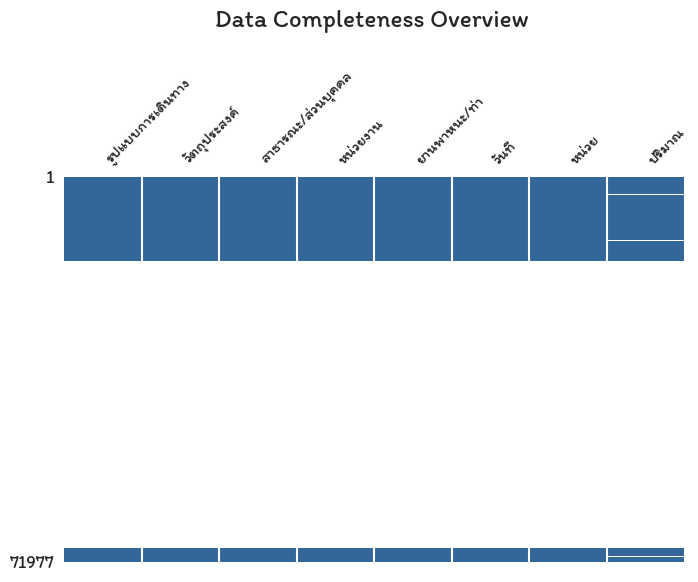

In [ ]:
# ============================================================
# 📊 DATA QUALITY CHECK: VISUALIZING MISSING VALUES
# ============================================================
# ใช้ Library missingno เพื่อสำรวจความสมบูรณ์ของข้อมูล (Data Completeness)
# ลักษณะกราฟ:
#   - แถบสีเข้ม (Dark): แสดงถึงข้อมูลที่มีอยู่ปกติ (Valid Data)
#   - ขีดสีขาว (Blank): แสดงถึงช่องว่างหรือข้อมูลที่ขาดหายไป (Missing Values / NaN)
# ------------------------------------------------------------

# 1. แสดงผล Matrix Chart เพื่อระบุตำแหน่งของข้อมูลที่หายไปตามดัชนีเวลา
fig = plt.figure(figsize=(8, 5))
msno.matrix(allinfo,  sparkline=False,fontsize=11, color=(0.2, 0.4, 0.6), ax=plt.gca())
plt.title('Data Completeness Overview ', fontsize=18, pad=30)
plt.show()

# 2. จัดการ Clean-up: ปิดการแจ้งเตือน (Warnings) เพื่อให้ Report สะอาดตา
warnings.filterwarnings('ignore')

In [ ]:
# ============================================================
# 🧹 DATA CLEANING & FINAL FILTERING: การลบแถวว่างและดักขอบเขตวันที่
# ============================================================

# 1. กำหนดเงื่อนไข (Condition) เพื่อระบุแถวที่ข้อมูลไม่สมบูรณ์
# โดยตรวจสอบแถวที่ไม่มีทั้ง 'วัตถุประสงค์' และ 'หน่วยงาน' (เป็นค่าว่างทั้งคู่)
condition = allinfo['วัตถุประสงค์'].isna() & allinfo['หน่วยงาน'].isna()

# 2. ทำการคัดกรอง (Filter) เอาเฉพาะแถวที่มีข้อมูล (ใช้เครื่องหมาย ~ เพื่อเลือกแถวที่ไม่ตรงกับเงื่อนไขว่าง)
# และใช้ .copy() เพื่อสร้าง DataFrame ใหม่ป้องกันปัญหา SettingWithCopyWarning
allinfo2 = allinfo[~condition].copy()

# 3. ควบคุมขอบเขตของข้อมูล (Data Boundaries) ให้ตรงตามโจทย์การวิเคราะห์
# แปลงคอลัมน์ 'วันที่' เป็น Datetime อีกครั้งเพื่อให้มั่นใจในรูปแบบข้อมูล (Format)
allinfo2['วันที่'] = pd.to_datetime(allinfo2['วันที่'], dayfirst=True, errors='coerce')

# ดักข้อมูลให้จบแค่เดือนกุมภาพันธ์ ปี 2026 เท่านั้น เพื่อป้องกันข้อมูลส่วนเกินหลุดเข้ามา
# เงื่อนไข: (เก็บปี 2025 ทั้งปี) หรือ (ถ้าเป็นปี 2026 ต้องมีค่าเดือนไม่เกินเดือน 2)
allinfo2 = allinfo2[
    (allinfo2['วันที่'].dt.year == 2025) |
    ((allinfo2['วันที่'].dt.year == 2026) & (allinfo2['วันที่'].dt.month <= 2))
]

# 4. แสดงรายงานสรุปช่วงเวลาของข้อมูล (Time Range Verification)
# เพื่อยืนยันว่าการดักข้อมูล (Filtering) สำเร็จตามแผนที่วางไว้
print(f"📊 ข้อมูลเริ่มตั้งแต่: {allinfo2['วันที่'].min().date()}")
print(f"🏁 ข้อมูลสิ้นสุดที่: {allinfo2['วันที่'].max().date()}")
print("-" * 30)

# แสดงรายละเอียดโครงสร้างข้อมูลหลังการ Clean (จำนวนแถว, คอลัมน์ และประเภทข้อมูล)
allinfo2.info()

📊 ข้อมูลเริ่มตั้งแต่: 2025-01-01
🏁 ข้อมูลสิ้นสุดที่: 2026-02-28
------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 18233 entries, 0 to 2536
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   รูปแบบการเดินทาง   18233 non-null  object        
 1   วัตถุประสงค์       18233 non-null  object        
 2   สาธารณะ/ส่วนบุคคล  18233 non-null  object        
 3   หน่วยงาน           18233 non-null  object        
 4   ยานพาหนะ/ท่า       18233 non-null  object        
 5   วันที่             18233 non-null  datetime64[ns]
 6   หน่วย              18233 non-null  object        
 7   ปริมาณ             17811 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 1.3+ MB


In [ ]:
# ============================================================
# 🔍 DATA VOID ANALYSIS: วิเคราะห์เจาะลึกตำแหน่งของค่าที่ว่าง
# ============================================================

# 1. แสดงจำนวนแถวทั้งหมดที่ยังขาดข้อมูลในคอลัมน์ 'ปริมาณ' (ผู้โดยสาร)
# เพื่อประเมินสัดส่วนความเสียหายของข้อมูลก่อนเริ่มขั้นตอนการวิเคราะห์เชิงสถิติ
print('📊 จำนวนข้อมูลที่ยังว่างอยู่ (Missing Values):', len(allinfo2[allinfo2['ปริมาณ'].isna()]), 'แถว')

# 2. จำแนกข้อมูลที่ว่างตามรายชื่อ 'ยานพาหนะ/ท่า'
# เพื่อระบุว่าสายการเดินทางใดที่มีปัญหาข้อมูลขาดหายมากที่สุด
# (ช่วยให้ทีมวิเคราะห์ได้ว่าเกิดจากเครื่องเก็บข้อมูลเสีย, ยังไม่เปิดบริการ หรือไฟล์ต้นทางไม่สมบูรณ์)
allinfo2[allinfo2['ปริมาณ'].isna()]['ยานพาหนะ/ท่า'].value_counts()

📊 จำนวนข้อมูลที่ยังว่างอยู่ (Missing Values): 422 แถว


,count
ยานพาหนะ/ท่า,
รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),197
รถยนต์ทุกประเภท (10 จุดสำรวจ),197
รถ บขส. ขาออกประเทศ,12
รถ บขส. ขาเข้าประเทศ,9
รถ บขส. และ รถร่วม,2
รถไฟ,1
รถไฟฟ้าสายสีน้ำเงิน,1
รถไฟฟ้าสายสีม่วง,1
รถไฟฟ้าสายสีเหลือง,1


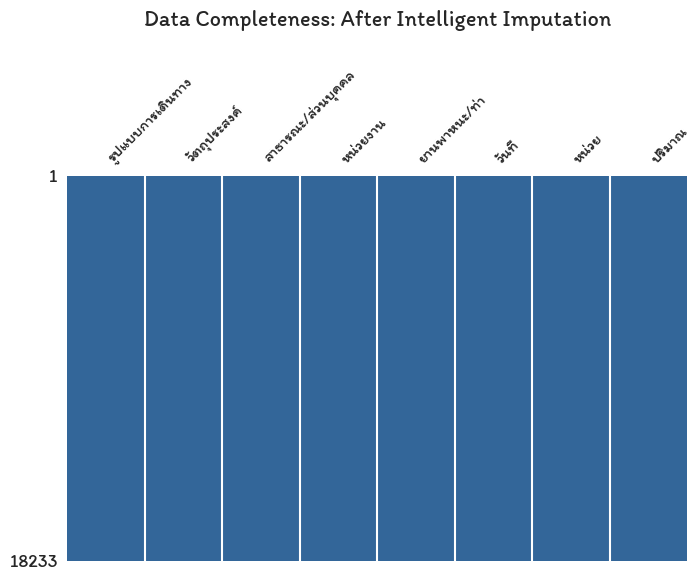

-------------------------------------------------------
                 FINAL QUALITY REPORT                  
-------------------------------------------------------
✨ ข้อมูลพร้อมใช้งาน 100% (จัดการทั้งแถวว่างและค่าปริมาณหายเรียบร้อย)
-------------------------------------------------------
Total Rows for Analysis: 18,233


In [ ]:
# ============================================================
# ⚙️ 1. SETUP & DATA CLEANING (จัดการแถวที่ว่างสนิท)
# ============================================================
warnings.filterwarnings('ignore')

# [Step 1] ลบแถวที่ "ไม่มีข้อมูลเลยในทุกคอลัมน์สำคัญ" ออกก่อน
# ถ้าเราไม่ลบแถวที่ว่างสนิท 74% นี้ออก การคำนวณสถิติจะเพี้ยนและกราฟจะดูไม่ได้เลย
essential_cols = ['ยานพาหนะ/ท่า', 'วันที่']
allinfo2 = allinfo.dropna(subset=essential_cols, how='all').copy()

# [Step 2] จัดการตัวเลข 'ปริมาณ'
allinfo2['ปริมาณ'] = allinfo2['ปริมาณ'].astype(str).str.replace(",", "", regex=True)
allinfo2['ปริมาณ'] = pd.to_numeric(allinfo2['ปริมาณ'], errors='coerce')
allinfo2['ปริมาณ'] = allinfo2['ปริมาณ'].replace(0, pd.NA)

# [Step 3] จัดการวันที่และสร้างตัวช่วย
allinfo2['วันที่'] = pd.to_datetime(allinfo2['วันที่'], format='%d/%m/%Y', errors='coerce')
allinfo2 = allinfo2.dropna(subset=['วันที่']) # ลบแถวที่วันที่ผิดเพี้ยน

allinfo2['day_of_week'] = allinfo2['วันที่'].dt.dayofweek
allinfo2['is_weekend'] = (allinfo2['day_of_week'] >= 5).astype(int)
allinfo2 = allinfo2.sort_values(['ยานพาหนะ/ท่า', 'วันที่'])

# ============================================================
# 🩹 2. DATA IMPUTATION (เติมค่าให้แถวที่มีชื่อสายแต่ยอดหาย)
# ============================================================

# [Method A] เติมด้วยข้อมูลวันเดียวกันจากสัปดาห์ก่อนหน้า (Shift 7 วัน)
allinfo2['ปริมาณ'] = allinfo2['ปริมาณ'].fillna(
    allinfo2.groupby('ยานพาหนะ/ท่า')['ปริมาณ'].shift(7)
)

# [Method B] เติมส่วนที่เหลือด้วยค่าเฉลี่ยของ "สายนั้นๆ" แยกตามประเภทวัน
allinfo2['ปริมาณ'] = allinfo2['ปริมาณ'].fillna(
    allinfo2.groupby(['ยานพาหนะ/ท่า', 'is_weekend'])['ปริมาณ'].transform('mean')
)

# [Method C] กรณีที่สายนั้นไม่มีข้อมูลเลยแม้แต่ยอดเดียว ให้เติม 0 (ป้องกัน NaN ตกค้าง)
allinfo2['ปริมาณ'] = allinfo2['ปริมาณ'].fillna(0)

allinfo2 = allinfo2.drop(columns=['day_of_week', 'is_weekend'])

# ============================================================
# 📊 3. VISUALIZATION & SUMMARY REPORT
# ============================================================
plt.figure(figsize=(8, 5))
msno.matrix(allinfo2, sparkline=False, fontsize=11, color=(0.2, 0.4, 0.6), ax=plt.gca())
plt.title('Data Completeness: After Intelligent Imputation', fontsize=16, pad=30)
plt.show()

missing_data = allinfo2.isnull().sum()
print("-" * 55)
print(f"{'FINAL QUALITY REPORT':^55}")
print("-" * 55)
if missing_data.sum() == 0:
    print("✨ ข้อมูลพร้อมใช้งาน 100% (จัดการทั้งแถวว่างและค่าปริมาณหายเรียบร้อย)")
else:
    print(missing_data[missing_data > 0])
print("-" * 55)
print(f"Total Rows for Analysis: {len(allinfo2):,}")

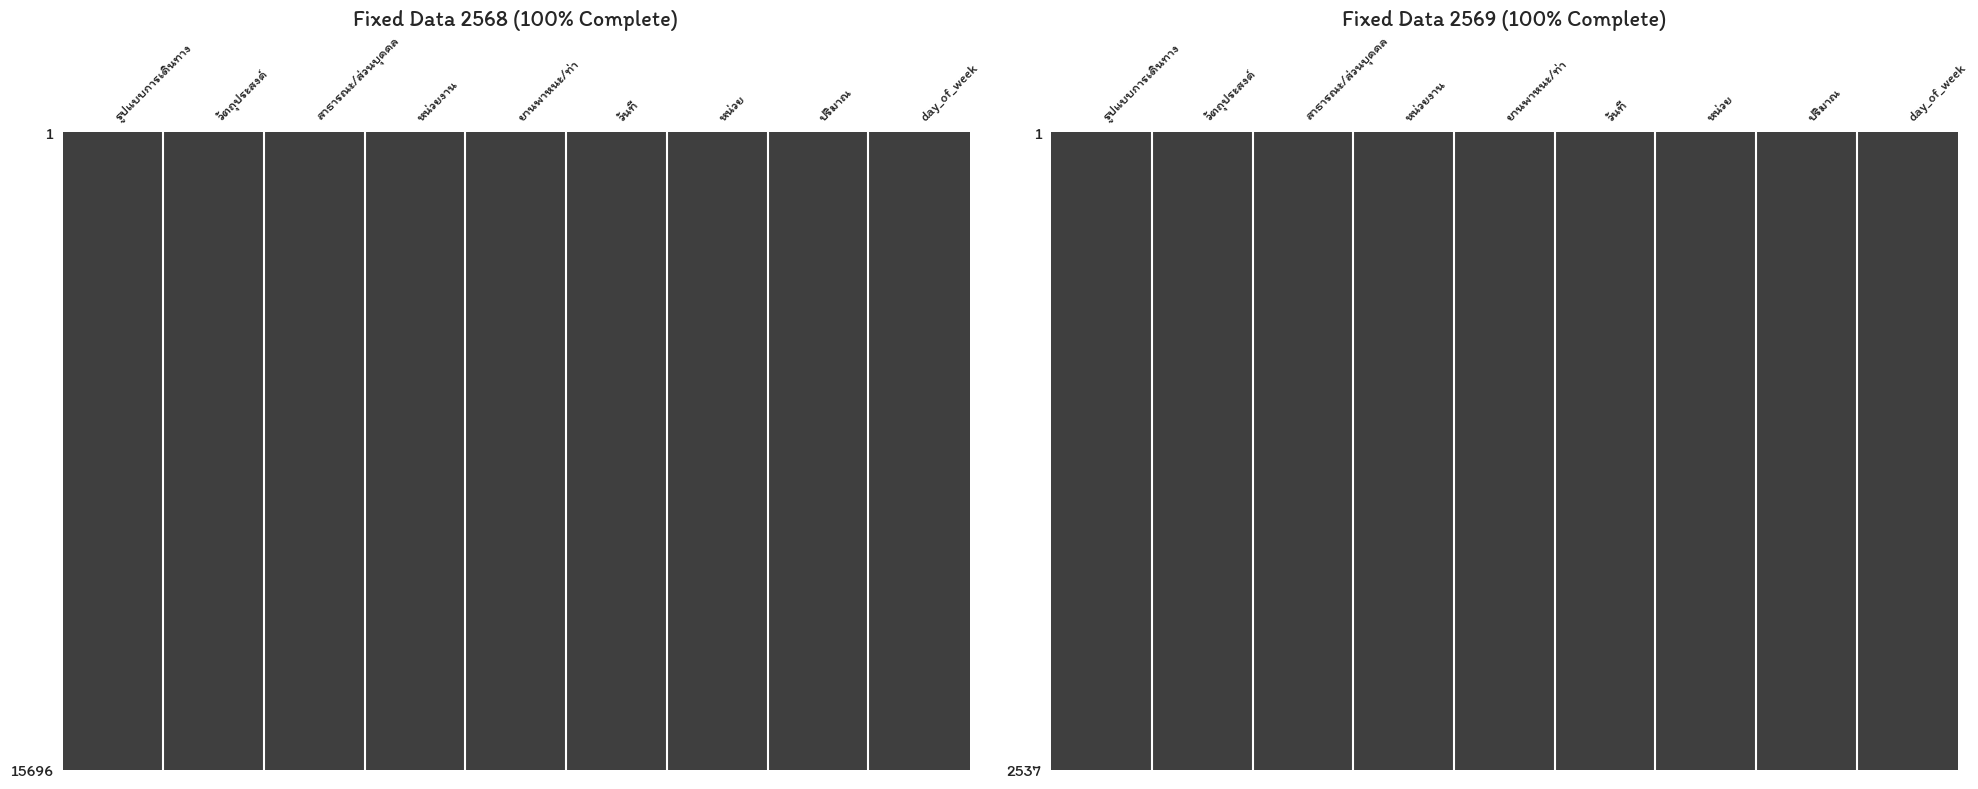

📌 สรุปค่าว่างคงเหลือปี 68: 0 จุด
📌 สรุปค่าว่างคงเหลือปี 69: 0 จุด


In [ ]:
# ============================================================
# 🛠️ DATA REHABILITATION: การซ่อมแซมและเติมเต็มข้อมูลที่สูญหาย
# ============================================================

# ปิดการแจ้งเตือน (Warnings) เพื่อให้การแสดงผล Report สะอาดตา
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 1. การเตรียมข้อมูลพื้นฐาน (Data Preprocessing)
# ------------------------------------------------------------
# แปลงคอลัมน์ 'ปริมาณ' ให้เป็นตัวเลข: ลบลูกน้ำ (,) ออกและจัดการค่าที่ไม่ใช่ตัวเลขให้เป็น NaN
allinfo2['ปริมาณ'] = allinfo2['ปริมาณ'].astype(str).str.replace(",", "", regex=True)
allinfo2['ปริมาณ'] = pd.to_numeric(allinfo2['ปริมาณ'], errors='coerce')

# จัดการข้อมูลวันที่ (DateTime) และสร้างคอลัมน์ 'day_of_week' (0=จันทร์, 6=อาทิตย์)
# เพื่อใช้เป็นเกณฑ์ในการเติมค่าเฉลี่ยตามพฤติกรรมการเดินทางรายวัน
allinfo2['วันที่'] = pd.to_datetime(allinfo2['วันที่'], format='%d/%m/%Y')
allinfo2['day_of_week'] = allinfo2['วันที่'].dt.dayofweek

# แยกชุดข้อมูลออกเป็นรายปี (2025 และ 2026) เพื่อป้องกันไม่ให้ค่าเฉลี่ยข้ามปีมาปนกัน
info68 = allinfo2[allinfo2['วันที่'].dt.year == 2025].copy()
info69 = allinfo2[allinfo2['วันที่'].dt.year == 2026].copy()

# ------------------------------------------------------------
# 2. การเติมเต็มข้อมูล (Double Layer Imputation Strategy)
# ------------------------------------------------------------
def repair_data(df):
    """ ฟังก์ชันสำหรับซ่อมแซมข้อมูลที่หายไปแบบเป็นลำดับขั้น (Waterfall Imputation) """

    # Layer 1: เติมด้วยค่าเฉลี่ยแยกตาม "สายรถ + วันในสัปดาห์"
    # (เช่น ถ้าวันจันทร์ของ BTS หายไป ให้เอาค่าเฉลี่ยของวันจันทร์อื่นๆ ในปีนั้นมาเติม)
    df['ปริมาณ'] = df.groupby(['ยานพาหนะ/ท่า', 'day_of_week'])['ปริมาณ'].transform(lambda x: x.fillna(x.mean()))

    # Layer 2: กรณีที่วันนั้นๆ หายไปทั้งปี ให้ใช้ "ค่าเฉลี่ยรวมของสายรถนั้น" มาเติมแทน
    df['ปริมาณ'] = df.groupby(['ยานพาหนะ/ท่า'])['ปริมาณ'].transform(lambda x: x.fillna(x.mean()))

    # Layer 3: ขั้นตอนสุดท้าย (Safety Net) ถ้ายังมีค่าว่าง ให้ใช้ค่าเฉลี่ยรวมของทั้งปีนั้นเติมให้เต็ม
    df['ปริมาณ'] = df['ปริมาณ'].fillna(df['ปริมาณ'].mean())
    return df

# ดำเนินการซ่อมแซมข้อมูลทั้งปี 2568 และ 2569
info68 = repair_data(info68)
info69 = repair_data(info69)

# ------------------------------------------------------------
# 3. การตรวจสอบผลลัพธ์ด้วยกราฟ (Data Completeness Visualization)
# ------------------------------------------------------------
# สร้างพื้นที่แสดงผลเปรียบเทียบ 2 ปี (Subplots: 1 Row, 2 Columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# แสดง Matrix Plot ปี 2568: เพื่อยืนยันว่าไม่มีแถบขาว (Missing) หลงเหลืออยู่
msno.matrix(info68, ax=ax1, sparkline=False, fontsize=10)
ax1.set_title('Fixed Data 2568 (100% Complete)', fontsize=16)

# แสดง Matrix Plot ปี 2569: ตรวจสอบความสมบูรณ์ของข้อมูลต้นปี 2026
msno.matrix(info69, ax=ax2, sparkline=False, fontsize=10)
ax2.set_title('Fixed Data 2569 (100% Complete)', fontsize=16)

plt.tight_layout()
plt.show()

# พิมพ์สรุปจำนวนค่าว่างคงเหลือเพื่อการันตีความถูกต้อง (ควรเป็น 0 ทุกจุด)
print(f"📌 สรุปค่าว่างคงเหลือปี 68: {info68['ปริมาณ'].isnull().sum()} จุด")
print(f"📌 สรุปค่าว่างคงเหลือปี 69: {info69['ปริมาณ'].isnull().sum()} จุด")

**🚆 ข้อ 1 — คนไทยเดินทางด้วยอะไรมากที่สุด?** <br>
Modal Share<br>
**โจทย์**<br>
จากข้อมูลปริมาณผู้โดยสารของระบบขนส่งทั้ง 4 รูปแบบหลัก

* รถไฟฟ้า BTS<br>
* รถไฟฟ้า MRT<br>
* Airport Rail Link<br>
* รถไฟชานเมืองสายสีแดง<br>

จงสร้างกราฟที่แสดงให้เห็นว่า<br>
* สัดส่วนการใช้ระบบขนส่งแต่ละประเภทเป็นอย่างไร<br>
* และรูปแบบใดที่ เติบโตหรือหดตัวมากที่สุด เมื่อเปรียบเทียบปี 2568 กับ 2569

      --- MEAN ANALYSIS: 2568 ---       
Mean for BTS      (2568): 723,267.90
Mean for MRT      (2568): 149,985.08
Mean for ARL      (2568): 65,631.39
Mean for Red Line (2568): 36,242.94

      --- MEAN ANALYSIS: 2569 ---       
Mean for BTS      (2569): 723,728.34
Mean for MRT      (2569): 157,337.92
Mean for ARL      (2569): 72,339.93
Mean for Red Line (2569): 38,048.42


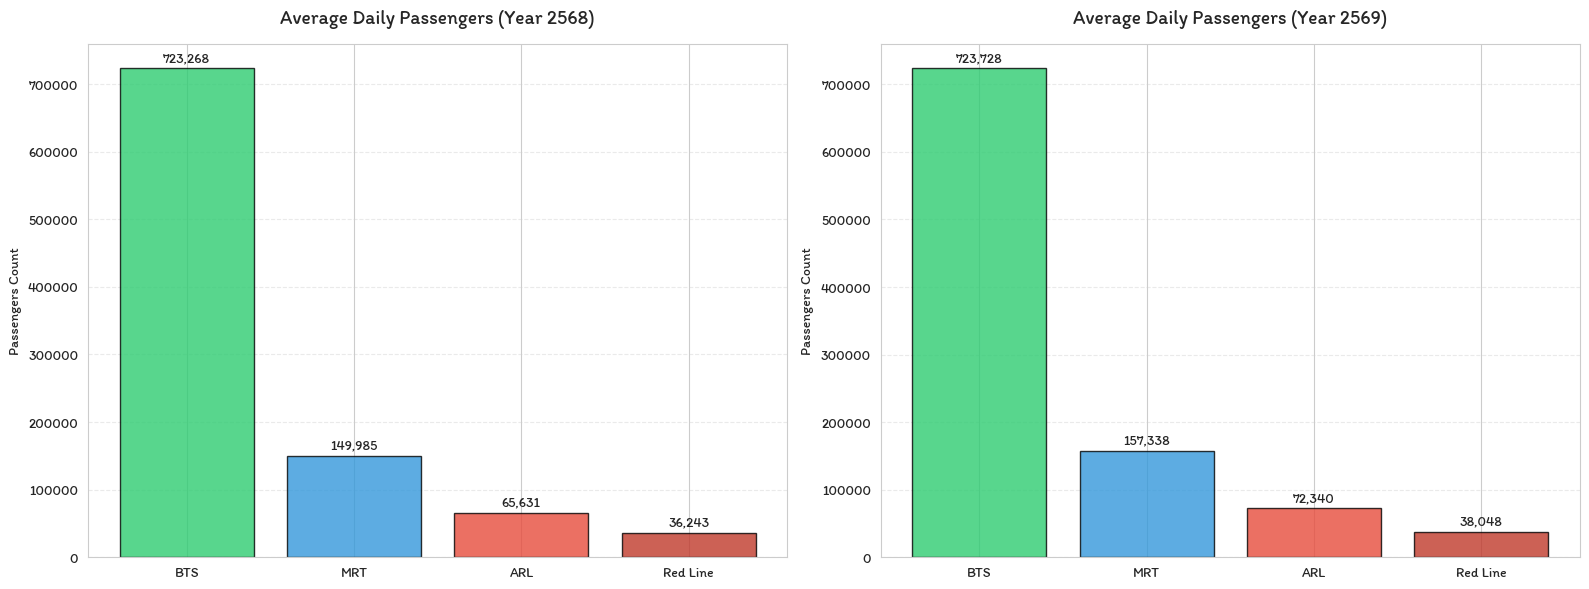

In [ ]:
# ============================================================
# 📊 COMPARATIVE ANALYSIS: การวิเคราะห์เปรียบเทียบปริมาณผู้โดยสารรายปี
# ============================================================

# 🛠️ 1. SETTINGS & SHARED CONFIGURATION: กำหนดกลุ่มเป้าหมายและธีมสี
# จัดกลุ่มรถไฟฟ้าตามค่ายผู้ให้บริการ (Operators) เพื่อเปรียบเทียบภาพรวมระดับโครงข่าย
targets = {
    'BTS': ['รถไฟฟ้า BTS'],
    'MRT': ['รถไฟฟ้าสายสีน้ำเงิน', 'รถไฟฟ้าสายสีม่วง', 'รถไฟฟ้าสายสีเหลือง', 'รถไฟฟ้าสายสีชมพู'],
    'ARL': ['รถไฟฟ้า ARL'],
    'Red Line': ['รถไฟฟ้าสายสีแดง']
}
colors = ['#2ECC71', '#3498DB', '#E74C3C', '#C0392B'] # เขียว(BTS), น้ำเงิน(MRT), แดง(ARL), แดงเข้ม(SRT)

# ============================================================
# 📅 2. PROCESSING DATA: วิเคราะห์ข้อมูลปี 2568
# ============================================================
# [Preprocessing] ทำความสะอาดข้อมูล: ลบคอมม่า, แปลงเป็นตัวเลข และจัดการวันที่
info68['ปริมาณ'] = pd.to_numeric(info68['ปริมาณ'].astype(str).str.replace(",", ""), errors='coerce')
info68['วันที่'] = pd.to_datetime(info68['วันที่'], format='%d/%m/%Y')
info68['day_of_week'] = info68['วันที่'].dt.dayofweek

# [Imputation] เติมค่าว่างด้วยค่าเฉลี่ยรายวัน (Day of Week) เพื่อรักษาพฤติกรรมการเดินทางรายสัปดาห์
info68['ปริมาณ'] = info68.groupby(['ยานพาหนะ/ท่า', 'day_of_week'])['ปริมาณ'].transform(lambda x: x.fillna(x.mean()))

# [Calculation] คำนวณค่าเฉลี่ยรายวันแยกตามกลุ่มรถไฟฟ้า
means68 = []
print(f"{'--- MEAN ANALYSIS: 2568 ---':^40}")
for name, lines in targets.items():
    avg = info68[info68['ยานพาหนะ/ท่า'].isin(lines)]['ปริมาณ'].mean()
    means68.append(avg)
    # เก็บค่าเฉลี่ยรายปีเพื่อใช้คำนวณอัตราการเติบโต (Growth Rate) ในภายหลัง
    if name == 'BTS': bts_mean68 = avg
    elif name == 'MRT': mrt_mean68 = avg
    elif name == 'ARL': arl_mean68 = avg
    elif name == 'Red Line': red_line_mean68 = avg
    print(f'Mean for {name:<8} (2568): {avg:,.2f}')

# ============================================================
# 📅 3. PROCESSING DATA: วิเคราะห์ข้อมูลปี 2569
# ============================================================
# ดำเนินการขั้นตอนเดียวกับปี 2568 เพื่อให้ฐานข้อมูลมีความเป็นธรรม (Standardized Comparison)
info69['ปริมาณ'] = pd.to_numeric(info69['ปริมาณ'].astype(str).str.replace(",", ""), errors='coerce')
info69['วันที่'] = pd.to_datetime(info69['วันที่'], format='%d/%m/%Y')
info69['day_of_week'] = info69['วันที่'].dt.dayofweek
info69['ปริมาณ'] = info69.groupby(['ยานพาหนะ/ท่า', 'day_of_week'])['ปริมาณ'].transform(lambda x: x.fillna(x.mean()))

means69 = []
print(f"\n{'--- MEAN ANALYSIS: 2569 ---':^40}")
for name, lines in targets.items():
    avg = info69[info69['ยานพาหนะ/ท่า'].isin(lines)]['ปริมาณ'].mean()
    means69.append(avg)
    if name == 'BTS': bts_mean69 = avg
    elif name == 'MRT': mrt_mean69 = avg
    elif name == 'ARL': arl_mean69 = avg
    elif name == 'Red Line': red_line_mean69 = avg
    print(f'Mean for {name:<8} (2569): {avg:,.2f}')

# ============================================================
# 📈 4. VISUALIZATION: แสดงผลเปรียบเทียบด้วยกราฟแท่ง (Side-by-Side)
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: แสดงผลปี 2568
bars68 = ax[0].bar(targets.keys(), means68, color=colors, edgecolor='black', alpha=0.8)
ax[0].set_title('Average Daily Passengers (Year 2568)', fontsize=14, fontweight='bold', pad=15)
ax[0].set_ylabel('Passengers Count')
ax[0].bar_label(bars68, fmt='{:,.0f}', padding=3, fontweight='bold')
ax[0].grid(axis='y', linestyle='--', alpha=0.4)

# Subplot 2: แสดงผลปี 2569
bars69 = ax[1].bar(targets.keys(), means69, color=colors, edgecolor='black', alpha=0.8)
ax[1].set_title('Average Daily Passengers (Year 2569)', fontsize=14, fontweight='bold', pad=15)
ax[1].set_ylabel('Passengers Count')
ax[1].bar_label(bars69, fmt='{:,.0f}', padding=3, fontweight='bold')
ax[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

--- ข้อมูลส่วนต่างจำนวนผู้โดยสารเฉลี่ย (คน) ---
BTS      :          460.44
MRT      :        7,352.84
ARL      :        6,708.54
Red Line :        1,805.48

--- สรุปอัตราการเติบโต (Percentage Growth) ---
BTS Growth      :       0.06%
MRT Growth      :       4.90%
ARL Growth      :      10.22%
Red Line Growth :       4.98%


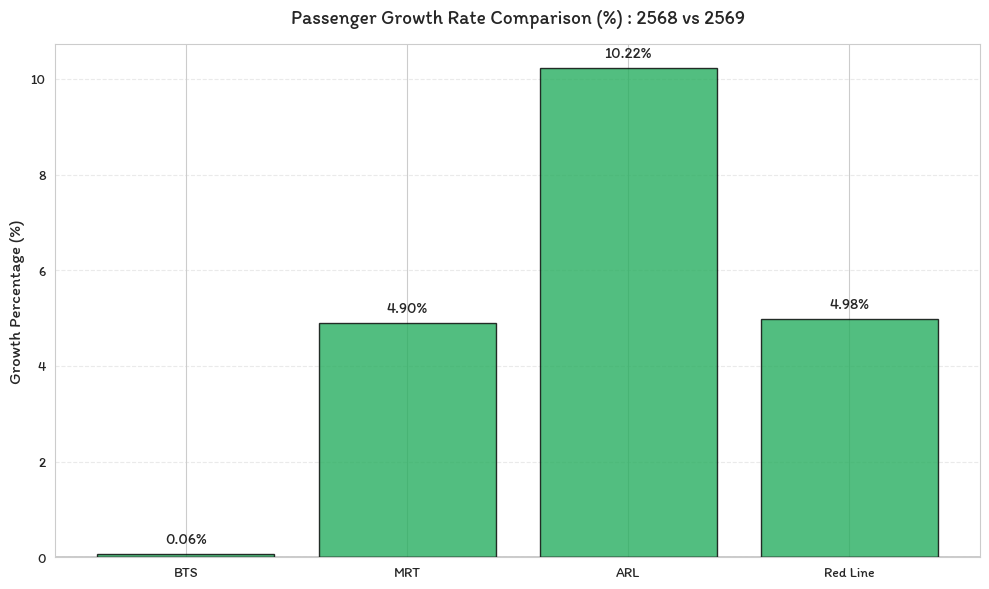

In [ ]:
# ============================================================
# 📈 GROWTH ANALYSIS: การวิเคราะห์ส่วนต่างและอัตราการเติบโต
# ============================================================

# --- 1. การคำนวณส่วนต่างเชิงปริมาณ (Absolute Difference) ---
# คำนวณจำนวนผู้โดยสารที่เพิ่มขึ้นหรือลดลง (คน) ระหว่างปี 2568 และ 2569
bts_diff = round(bts_mean69 - bts_mean68, 2)
mrt_diff = round(mrt_mean69 - mrt_mean68, 2)
arl_diff = round(arl_mean69 - arl_mean68, 2)
red_diff = round(red_line_mean69 - red_line_mean68, 2)

print(f"{'--- ข้อมูลส่วนต่างจำนวนผู้โดยสารเฉลี่ย (คน) ---':^45}")
print(f"BTS      : {bts_diff:>15,.2f}")
print(f"MRT      : {mrt_diff:>15,.2f}")
print(f"ARL      : {arl_diff:>15,.2f}")
print(f"Red Line : {red_diff:>15,.2f}")

# --- 2. การคำนวณอัตราการเติบโตเชิงร้อยละ (Percentage Growth) ---
# สูตรการหา % Growth = ((ปีใหม่ - ปีเก่า) / ปีเก่า) * 100
# เพื่อเปรียบเทียบสัดส่วนการขยายตัวของแต่ละโครงข่ายอย่างยุติธรรม
bts_growth = ((bts_mean69 - bts_mean68) / bts_mean68) * 100
mrt_growth = ((mrt_mean69 - mrt_mean68) / mrt_mean68) * 100
arl_growth = ((arl_mean69 - arl_mean68) / arl_mean68) * 100
red_growth = ((red_line_mean69 - red_line_mean68) / red_line_mean68) * 100

print(f"\n{'--- สรุปอัตราการเติบโต (Percentage Growth) ---':^45}")
print(f"BTS Growth      : {bts_growth:>10.2f}%")
print(f"MRT Growth      : {mrt_growth:>10.2f}%")
print(f"ARL Growth      : {arl_growth:>10.2f}%")
print(f"Red Line Growth : {red_growth:>10.2f}%")

# --- 3. การแสดงผลด้วยกราฟการเติบโต (Growth Rate Visualization) ---
# สร้างแผนภูมิแท่งเพื่อเปรียบเทียบ % Growth ของแต่ละค่ายให้เห็นภาพชัดเจน
plt.figure(figsize=(10, 6))
labels = ['BTS', 'MRT', 'ARL', 'Red Line']
growth_rates = [bts_growth, mrt_growth, arl_growth, red_growth]

# กำหนดเงื่อนไขสี: สีเขียวเมื่อมีการเติบโตเป็นบวก (Positive) และสีแดงเมื่อติดลบ (Negative)
colors = ['#27ae60' if x >= 0 else '#e74c3c' for x in growth_rates]

bars = plt.bar(labels, growth_rates, color=colors, edgecolor='black', alpha=0.8)
plt.axhline(0, color='black', linewidth=1) # เพิ่มเส้น Baseline ที่ระดับ 0% เพื่อเป็นจุดอ้างอิง

plt.title('Passenger Growth Rate Comparison (%) : 2568 vs 2569', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Growth Percentage (%)', fontsize=12)
plt.bar_label(bars, fmt='%.2f%%', padding=5, fontweight='bold', fontsize=11) # แสดงตัวเลข % กำกับบนแท่งกราฟ
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

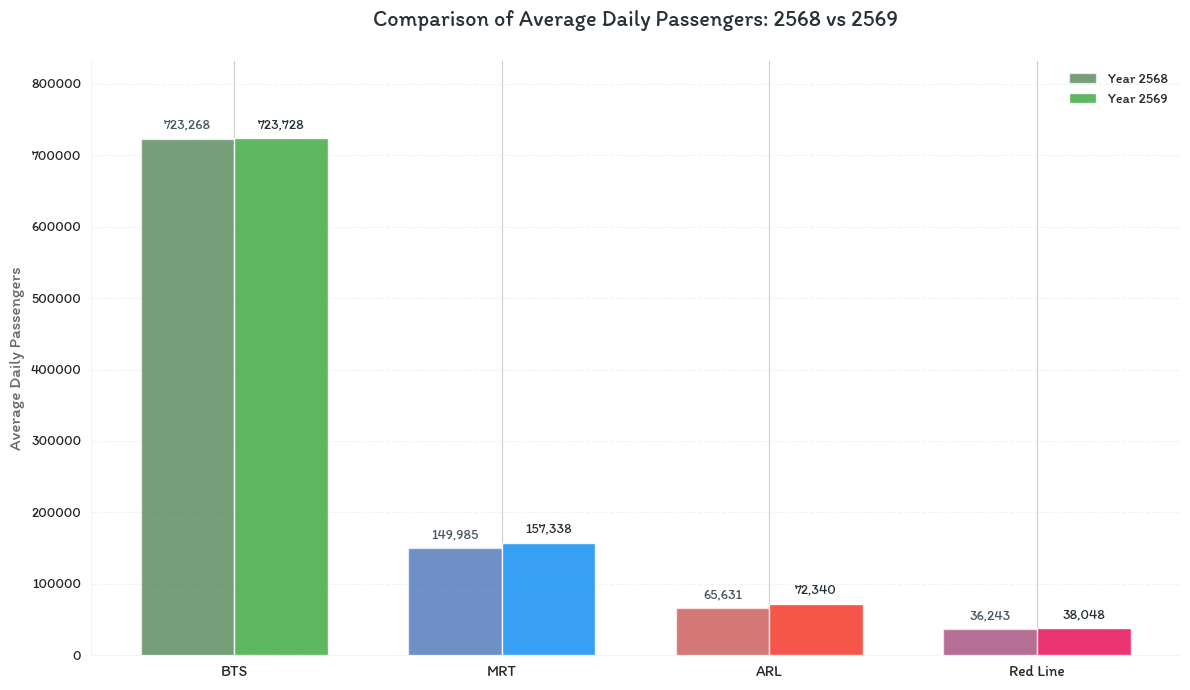

In [ ]:
# ============================================================
# 📊 FINAL COMPARISON: กราฟเปรียบเทียบภาพรวมผู้โดยสารรายปี (2568 vs 2569)
# ============================================================

# 🛠️ 1. เตรียมข้อมูลสำหรับพล็อต (Data Preparation)
labels = ['BTS', 'MRT', 'ARL', 'Red Line']
means_2568 = [bts_mean68, mrt_mean68, arl_mean68, red_line_mean68]
means_2569 = [bts_mean69, mrt_mean69, arl_mean69, red_line_mean69]

# กำหนดตำแหน่งบนแกน X และความกว้างของแท่งกราฟ
x = np.arange(len(labels))
width = 0.35  # ขนาดความกว้างของแท่งเพื่อให้วางคู่กันได้สวยงาม

# 🎨 2. สร้างพื้นที่กราฟและกำหนดสี (Visualization & Color Palette)
fig, ax = plt.subplots(figsize=(12, 7))

# --- ปรับโทนสีให้สอดคล้องกับรายงานส่วนอื่นๆ (Brand Consistency) ---
# ปี 2568: ใช้สีเข้มขึ้นเล็กน้อยเพื่อให้ดูเป็นข้อมูลฐาน (Baseline)
# ปี 2569: ใช้สีสว่างขึ้นเพื่อเน้นข้อมูลปัจจุบัน (Current Period)
colors_68 = ['#1B5E20', '#0D47A1', '#B71C1C', '#880E4F'] # เขียวเข้ม, น้ำเงินเข้ม, แดงเข้ม
colors_69 = ['#4CAF50', '#2196F3', '#F44336', '#E91E63'] # เขียวสว่าง, น้ำเงินสว่าง, แดงสว่าง

rects1 = ax.bar(x - width/2, means_2568, width, label='Year 2568', color=colors_68, alpha=0.6)
rects2 = ax.bar(x + width/2, means_2569, width, label='Year 2569', color=colors_69, alpha=0.9)

# 🖌️ 3. การตกแต่งองค์ประกอบกราฟ (Chart Refinement)
ax.set_ylabel('Average Daily Passengers', fontsize=12, fontweight='bold', alpha=0.7)
ax.set_title('Comparison of Average Daily Passengers: 2568 vs 2569',
             fontsize=16, pad=25, fontweight='bold', color='#263238')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')

# ปรับ Legend (คำอธิบายสัญลักษณ์) ให้ดูสะอาดตาและไม่บังข้อมูล
ax.legend(loc='upper right', fontsize=10, frameon=False)

# 🏷️ 4. การติดป้ายกำกับตัวเลข (Data Labels)
# แสดงตัวเลขผู้โดยสารเฉลี่ยบนหัวแท่งกราฟเพื่อให้อ่านค่าได้ทันทีโดยไม่ต้องกะสายตา
ax.bar_label(rects1, padding=5, fmt='{:,.0f}', fontsize=10, color='#455A64', fontweight='bold')
ax.bar_label(rects2, padding=5, fmt='{:,.0f}', fontsize=10, color='#263238', fontweight='bold')

# 📏 5. ปรับแต่งสเกลและเส้นตาราง (Grid & Spines)
# เผื่อพื้นที่ด้านบนกราฟ 15% เพื่อไม่ให้ตัวเลข Label ติดขอบบนเกินไป
max_val = max(max(means_2568), max(means_2569))
ax.set_ylim(0, max_val * 1.15)

# ลบเส้นขอบกราฟที่ไม่จำเป็น (Minimalist Style) เพื่อเน้นจุดสนใจไปที่ตัวข้อมูล
ax.grid(axis='y', linestyle='--', alpha=0.3, color='#CFD8DC')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0.2)
ax.spines['bottom'].set_alpha(0.2)

fig.tight_layout()
plt.show()

**🚇 ข้อ 2 — รถไฟฟ้าในกรุงเทพฯ แต่ละสายมีพฤติกรรมผู้โดยสารต่างกันอย่างไร?** <br>
Urban Rail Comparison<br>
**โจทย์**<br>
จากข้อมูลผู้โดยสารรถไฟฟ้าทุกสาย<br>

* BTS
* MRT สีน้ำเงิน
* MRT สีม่วง
* MRT สีเหลือง
* MRT สีชมพู
* Airport Rail Link
* รถไฟชานเมืองสายสีแดง<br>

จงสร้างกราฟที่เปรียบเทียบ
* ปริมาณผู้โดยสารของแต่ละสาย
* และรูปแบบการเปลี่ยนแปลงของผู้โดยสารรายวัน<br>

พร้อมวิเคราะห์ว่า
* สายใดมี ความผันผวนของผู้โดยสารสูง
* สายใดมี ฐานผู้โดยสารที่เสถียร

✅ Sum for รถไฟฟ้า BTS          : 306,692,754
✅ Sum for รถไฟฟ้า MRT สีน้ำเงิน  : 181,720,949
✅ Sum for รถไฟฟ้า MRT สีม่วง   : 28,692,847
✅ Sum for รถไฟฟ้า MRT สีเหลือง  : 19,372,413
✅ Sum for รถไฟฟ้า MRT สีชมพู   : 26,323,749
✅ Sum for รถไฟฟ้า ARL          : 28,223,515
✅ Sum for รถไฟชานเมืองสายสีแดง : 15,473,531


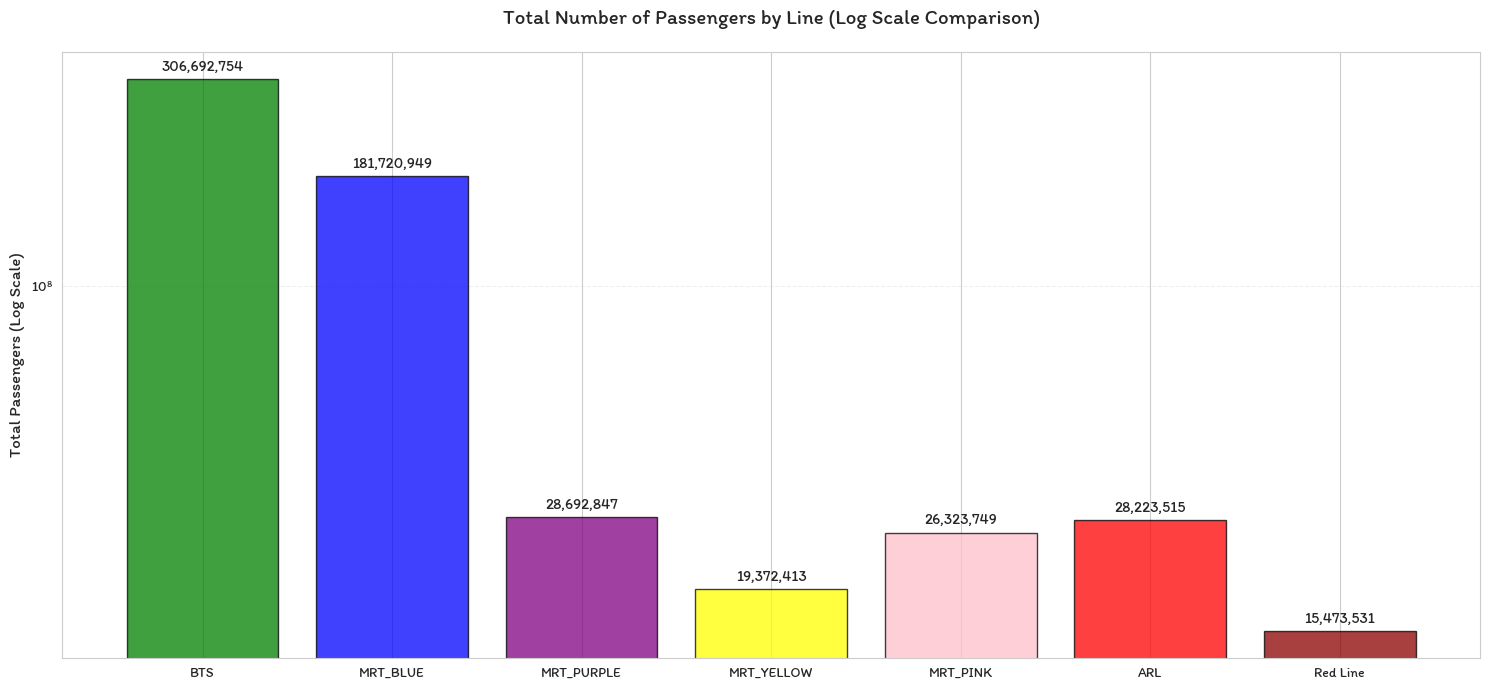

In [ ]:
# ============================================================
# 🚈 TOTAL RIDERSHIP ANALYSIS: สรุปยอดผู้โดยสารรวมทุกโครงข่าย (2568 - 2569)
# ============================================================

# --- 1. การคำนวณยอดผู้โดยสารรวมสะสมแยกตามรายสาย (Aggregation) ---
# ทำการรวมยอด (Sum) จากข้อมูลทั้งปี 2568 และ 2 เดือนแรกของปี 2569

# รถไฟฟ้า BTS
bts = info68[info68['ยานพาหนะ/ท่า']=='รถไฟฟ้า BTS']['ปริมาณ'].sum() + \
      info69[info69['ยานพาหนะ/ท่า']=='รถไฟฟ้า BTS']['ปริมาณ'].sum()
print(f'✅ Sum for รถไฟฟ้า BTS          : {bts:,.0f}')

# รถไฟฟ้า MRT (สายสีน้ำเงิน)
mrt_blue = info68[info68['ยานพาหนะ/ท่า']=='รถไฟฟ้าสายสีน้ำเงิน']['ปริมาณ'].sum() + \
           info69[info69['ยานพาหนะ/ท่า']=='รถไฟฟ้าสายสีน้ำเงิน']['ปริมาณ'].sum()
print(f'✅ Sum for รถไฟฟ้า MRT สีน้ำเงิน  : {mrt_blue:,.0f}')

# รถไฟฟ้า MRT (สายสีม่วง)
mrt_purple = info68[info68['ยานพาหนะ/ท่า']=='รถไฟฟ้าสายสีม่วง']['ปริมาณ'].sum() + \
             info69[info69['ยานพาหนะ/ท่า']=='รถไฟฟ้าสายสีม่วง']['ปริมาณ'].sum()
print(f'✅ Sum for รถไฟฟ้า MRT สีม่วง   : {mrt_purple:,.0f}')

# รถไฟฟ้า MRT (สายสีเหลือง)
mrt_yellow = info68[info68['ยานพาหนะ/ท่า']=='รถไฟฟ้าสายสีเหลือง']['ปริมาณ'].sum() + \
              info69[info69['ยานพาหนะ/ท่า']=='รถไฟฟ้าสายสีเหลือง']['ปริมาณ'].sum()
print(f'✅ Sum for รถไฟฟ้า MRT สีเหลือง  : {mrt_yellow:,.0f}')

# รถไฟฟ้า MRT (สายสีชมพู)
mrt_pink = info68[info68['ยานพาหนะ/ท่า']=='รถไฟฟ้าสายสีชมพู']['ปริมาณ'].sum() + \
            info69[info69['ยานพาหนะ/ท่า']=='รถไฟฟ้าสายสีชมพู']['ปริมาณ'].sum()
print(f'✅ Sum for รถไฟฟ้า MRT สีชมพู   : {mrt_pink:,.0f}')

# รถไฟฟ้า ARL (Airport Rail Link)
arl = info68[info68['ยานพาหนะ/ท่า']=='รถไฟฟ้า ARL']['ปริมาณ'].sum() + \
      info69[info69['ยานพาหนะ/ท่า']=='รถไฟฟ้า ARL']['ปริมาณ'].sum()
print(f'✅ Sum for รถไฟฟ้า ARL          : {arl:,.0f}')

# รถไฟฟ้าสายสีแดง (SRT Red Line)
red_line = info68[info68['ยานพาหนะ/ท่า']=='รถไฟฟ้าสายสีแดง']['ปริมาณ'].sum() + \
           info69[info69['ยานพาหนะ/ท่า']=='รถไฟฟ้าสายสีแดง']['ปริมาณ'].sum()
print(f'✅ Sum for รถไฟชานเมืองสายสีแดง : {red_line:,.0f}')

# --- 2. การสร้างแผนภูมิเปรียบเทียบ (Data Visualization) ---

plt.figure(figsize=(15, 7))
plt.ticklabel_format(style='plain', axis='y') # ป้องกันการแสดงผลแกน Y เป็นเลขยกกำลัง (Scientific Notation)

# เตรียมข้อมูลสำหรับการพล็อต
labels = ['BTS', 'MRT_BLUE', 'MRT_PURPLE', 'MRT_YELLOW', 'MRT_PINK', 'ARL', 'Red Line']
values = [bts, mrt_blue, mrt_purple, mrt_yellow, mrt_pink, arl, red_line]
line_colors = ['green', 'blue', 'purple', 'yellow', 'pink', 'red', 'darkred']

# วาดกราฟแท่ง (Bar Chart)
bars = plt.bar(labels, values, color=line_colors, edgecolor='black', alpha=0.75)

# [เทคนิคพิเศษ] ใช้ Logarithmic Scale สำหรับแกน Y
# เนื่องจากปริมาณผู้โดยสารแต่ละสายมีความต่างกันมาก (Scale Gap)
# การใช้ Log Scale จะช่วยให้เห็นสัดส่วนของสายที่มีคนน้อยได้ชัดเจนขึ้นบนกราฟเดียวกัน
plt.yscale('log')

# ใส่ตัวเลขจำนวนผู้โดยสารจริงกำกับบนหัวแท่งกราฟ (Data Labels)
# สำคัญมากเมื่อใช้ Log Scale เพื่อให้ผู้อ่านทราบค่าที่แท้จริงโดยไม่ต้องกะระยะจากแกน
plt.bar_label(bars, fmt='{:,.0f}', padding=3, fontweight='bold', fontsize=11)

plt.title('Total Number of Passengers by Line (Log Scale Comparison)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Total Passengers (Log Scale)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3) # เพิ่มเส้นตารางเพื่อให้อ่านค่าได้ง่ายขึ้น

plt.tight_layout()
plt.show()

           📊 PASSENGER STABILITY ANALYSIS (CV REPORT)            
      Line    Mean      SD CV (%)
       ARL  66,565  11,719 17.61%
       BTS 723,332 146,827 20.30%
  Red Line  36,494   7,452 20.42%
MRT Yellow  45,690   9,663 21.15%
  MRT Blue 428,587 100,616 23.48%
  MRT Pink  62,084  15,976 25.73%
MRT Purple  67,672  19,456 28.75%

💡 [ สรุปผลการวิเคราะห์ความผันผวน ]
✅ สายที่มี 'ความเสถียร' สูงสุด: ARL
   - มีค่า CV ต่ำที่สุด สะท้อนถึงกลุ่มผู้ใช้บริการหลักที่เป็นกลุ่มเดินทางประจำ (Workforce/Student)

⚠️ สายที่มี 'ความผันผวน' สูงสุด: MRT Purple
   - มีค่า CV สูงที่สุด ข้อมูลมีความเหวี่ยง (Volatility) มาก อาจได้รับผลกระทบจากวันหยุด/กิจกรรมพิเศษสูง


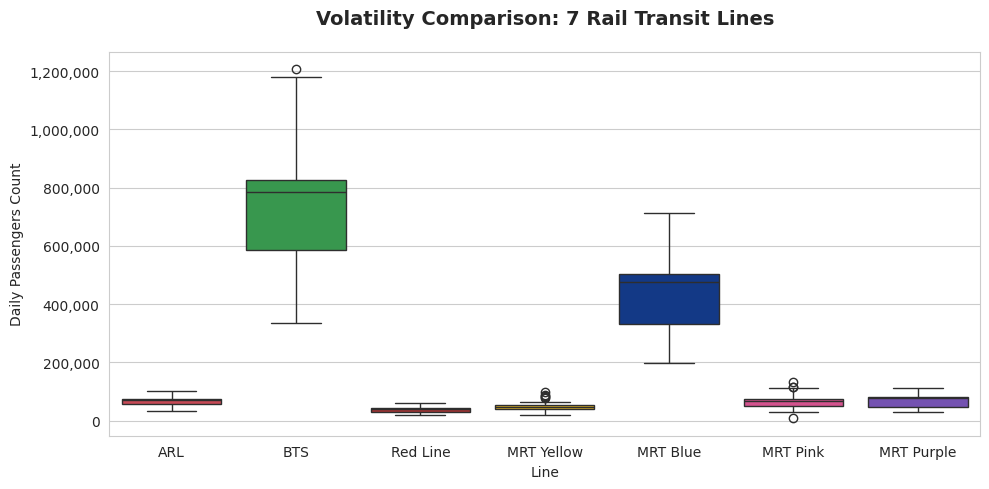

In [ ]:
# ============================================================
# 📉 VOLATILITY & STABILITY ANALYSIS: วิเคราะห์ความผันผวนของแต่ละสาย
# ============================================================

# 🛠️ 1. ตั้งค่า Mapping ชื่อภาษาอังกฤษและสีประจำสาย (Corporate Identity)
# เปลี่ยนชื่อให้เป็นสากลและกำหนด Code สีที่ตรงกับอัตลักษณ์ของแต่ละโครงการ
rename_map = {
    'รถไฟฟ้า BTS': 'BTS',
    'รถไฟฟ้าสายสีน้ำเงิน': 'MRT Blue',
    'รถไฟฟ้าสายสีม่วง': 'MRT Purple',
    'รถไฟฟ้าสายสีเหลือง': 'MRT Yellow',
    'รถไฟฟ้าสายสีชมพู': 'MRT Pink',
    'รถไฟฟ้า ARL': 'ARL',
    'รถไฟฟ้าสายสีแดง': 'Red Line'
}
custom_palette = {
    'BTS': '#28a745', 'MRT Blue': '#003399', 'MRT Purple': '#6f42c1',
    'MRT Yellow': '#ffc107', 'MRT Pink': '#e83e8c', 'ARL': '#dc3545', 'Red Line': '#b22222'
}

# 🛠️ 2. การเตรียมข้อมูลและคำนวณสถิติเชิงลึก (Statistical Calculation)
target_trains = list(rename_map.keys())
df_plot = allinfo2[allinfo2['ยานพาหนะ/ท่า'].isin(target_trains)].copy()
df_plot['Line'] = df_plot['ยานพาหนะ/ท่า'].map(rename_map)

stats_list = []
for eng_name in rename_map.values():
    data = df_plot[df_plot['Line'] == eng_name]['ปริมาณ']
    if not data.empty:
        m, s = data.mean(), data.std()
        # คำนวณ CV (%) = (ส่วนเบี่ยงเบนมาตรฐาน / ค่าเฉลี่ย) * 100
        # ใช้สำหรับวัด "ความเหวี่ยง" ของข้อมูลโดยไม่เกี่ยงขนาดฐานผู้โดยสาร
        stats_list.append({'Line': eng_name, 'Mean': m, 'SD': s, 'CV (%)': (s/m)*100})

# เรียงลำดับจากสายที่ 'เสถียรที่สุด' (CV น้อย) ไปหา 'ผันผวนที่สุด' (CV มาก)
df_stats = pd.DataFrame(stats_list).sort_values('CV (%)').reset_index(drop=True)

# 📊 3. แสดงผลตารางรายงานสถิติ (CV Report)
print(f"{'='*65}")
print(f"{'📊 PASSENGER STABILITY ANALYSIS (CV REPORT)':^65}")
print(f"{'='*65}")
print(df_stats.to_string(index=False, formatters={'Mean': '{:,.0f}'.format, 'SD': '{:,.0f}'.format, 'CV (%)': '{:.2f}%'.format}))
print(f"{'='*65}")

# 📝 4. ส่วนสรุปและอภิปรายผลการวิเคราะห์ (Executive Summary)
stable_line = df_stats.iloc[0]['Line']
volatile_line = df_stats.iloc[-1]['Line']

print(f"\n💡 [ สรุปผลการวิเคราะห์ความผันผวน ]")
print(f"✅ สายที่มี 'ความเสถียร' สูงสุด: {stable_line}")
print(f"   - มีค่า CV ต่ำที่สุด สะท้อนถึงกลุ่มผู้ใช้บริการหลักที่เป็นกลุ่มเดินทางประจำ (Workforce/Student)")
print(f"\n⚠️ สายที่มี 'ความผันผวน' สูงสุด: {volatile_line}")
print(f"   - มีค่า CV สูงที่สุด ข้อมูลมีความเหวี่ยง (Volatility) มาก อาจได้รับผลกระทบจากวันหยุด/กิจกรรมพิเศษสูง")

# 🎨 5. การสร้างกราฟ Box Plot (Visualizing Dispersion)
# แสดงการกระจายตัวของข้อมูลเพื่อดูค่ากลาง (Median) และค่าผิดปกติ (Outliers)
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")
# วางลำดับ Box ตามความเสถียรจากน้อยไปมาก (ตามค่า CV)
ax = sns.boxplot(data=df_plot, x='Line', y='ปริมาณ', order=df_stats['Line'].values, palette=custom_palette)

plt.title('Volatility Comparison: 7 Rail Transit Lines', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Daily Passengers Count')
# ปรับตัวเลขแกน Y ให้แสดงคอมม่าอ่านง่าย
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

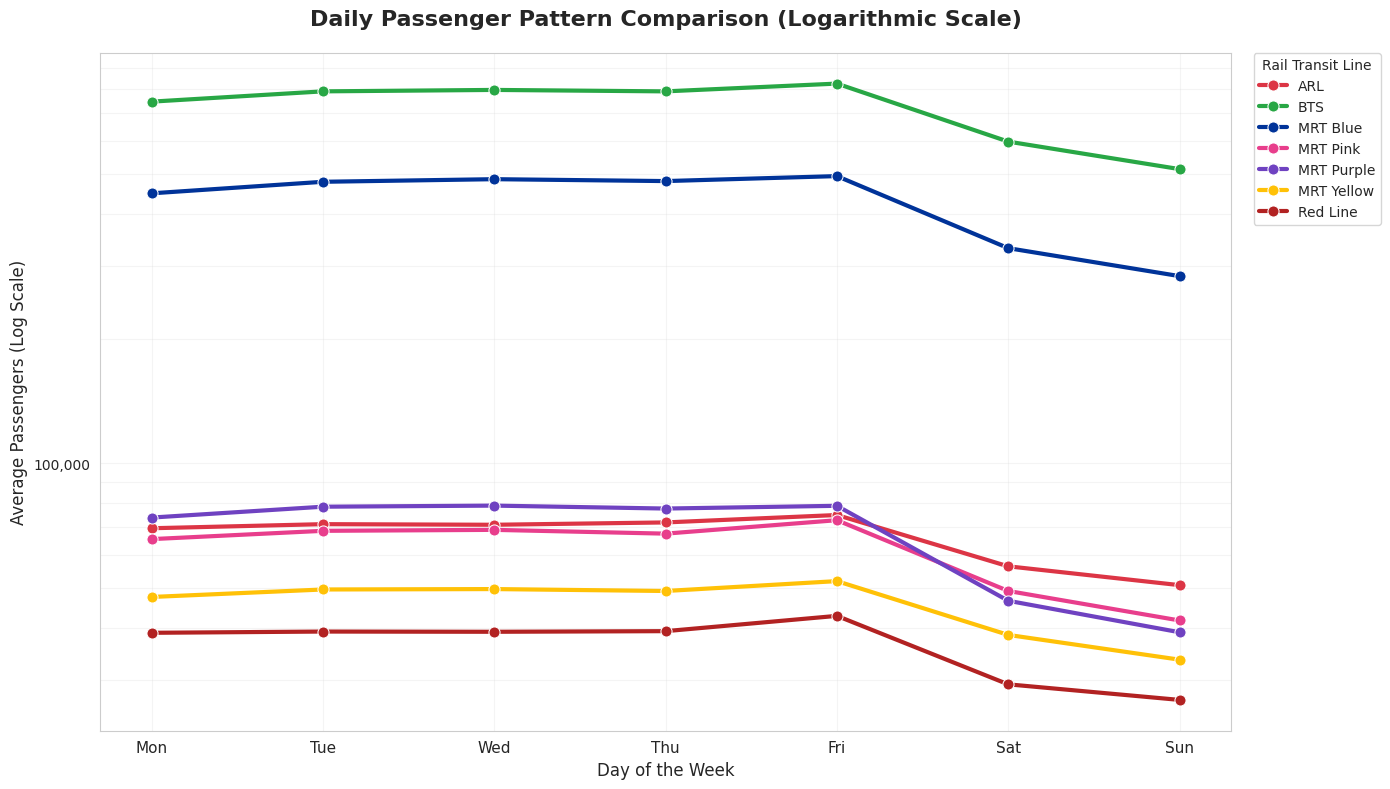

            🔍 ANALYSIS INSIGHT: WEEKLY PATTERN (LOG SCALE)            
1. สเกลลอการิทึม (Log Scale):
   - ช่วยให้เราเห็น 'พฤติกรรม' ของทุกสายทางได้ในเฟรมเดียว แม้ฐานผู้โดยสารจะต่างกันมาก
2. การวิเคราะห์ความชัน (Slope Analysis):
   - หากเส้นกราฟดิ่งลง (ช่วงวันเสาร์-อาทิตย์) ด้วยมุมที่ชันเท่ากัน 
     สะท้อนว่าทุกสายมี 'สัดส่วน' การลดลงของผู้โดยสารในช่วงวันหยุดที่ใกล้เคียงกัน
3. จุดเด่นของการเดินทาง:
   - ช่วยระบุสายที่มีผู้โดยสารคงที่ตลอดสัปดาห์ (เส้นขนาน) เทียบกับสายที่เน้นวันทำงาน (เส้นหักมุม)


In [ ]:
# ============================================================
# 📅 WEEKLY MOBILITY PATTERN: วิเคราะห์พฤติกรรมการเดินทางรายสัปดาห์
# ============================================================

# 🛠️ 1. การเตรียมข้อมูลสำหรับวิเคราะห์รูปแบบ 7 วัน (Weekly Preparation)
# แปลงชื่อสายรถไฟฟ้าและจัดกลุ่มข้อมูลตามวันในสัปดาห์ (Day of Week)
rename_map = {
    'รถไฟฟ้า BTS': 'BTS',
    'รถไฟฟ้าสายสีน้ำเงิน': 'MRT Blue',
    'รถไฟฟ้าสายสีม่วง': 'MRT Purple',
    'รถไฟฟ้าสายสีเหลือง': 'MRT Yellow',
    'รถไฟฟ้าสายสีชมพู': 'MRT Pink',
    'รถไฟฟ้า ARL': 'ARL',
    'รถไฟฟ้าสายสีแดง': 'Red Line'
}

target_trains = list(rename_map.keys())
df_weekly = allinfo2[allinfo2['ยานพาหนะ/ท่า'].isin(target_trains)].copy()
df_weekly['Line'] = df_weekly['ยานพาหนะ/ท่า'].map(rename_map)
df_weekly['วันที่'] = pd.to_datetime(df_weekly['วันที่'])
df_weekly['day_of_week'] = df_weekly['วันที่'].dt.dayofweek

# คำนวณค่าเฉลี่ยผู้โดยสารแยกตามสายและตามวัน (จันทร์-อาทิตย์)
weekly_avg = df_weekly.groupby(['Line', 'day_of_week'])['ปริมาณ'].mean().reset_index()

# ============================================================
# 📈 2. การสร้างกราฟเส้นเปรียบเทียบแบบ Logarithmic Scale
# ============================================================
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# กำหนดสีประจำสายรถไฟฟ้าให้สอดคล้องกับรายงานส่วนอื่นๆ
custom_palette = {
    'BTS': '#28a745', 'MRT Blue': '#003399', 'MRT Purple': '#6f42c1',
    'MRT Yellow': '#ffc107', 'MRT Pink': '#e83e8c', 'ARL': '#dc3545', 'Red Line': '#b22222'
}

# วาดกราฟเส้นแสดงแนวโน้ม (Trend Line) พร้อมจุด Marker
ax = sns.lineplot(
    data=weekly_avg,
    x='day_of_week',
    y='ปริมาณ',
    hue='Line',
    marker='o',
    palette=custom_palette,
    linewidth=3,
    markersize=8
)

# 🚩 [Strategic Choice] ตั้งค่าแกน Y เป็น Log Scale
# เพื่อลดช่องว่างระหว่างสายที่มีผู้โดยสารหลักแสน (BTS) และหลักหมื่น (Red Line)
# ทำให้สามารถสังเกต "อัตราการเปลี่ยนแปลง (Rate of Change)" ของทุกสายได้พร้อมกัน
ax.set_yscale('log')

# กำหนดชื่อวันบนแกน X (Labels)
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.xticks(range(7), day_labels, fontsize=11)

# ปรับแต่งตัวเลขบนแกน Y ให้แสดงเป็นจำนวนเต็มที่มีคอมม่า (อ่านง่ายขึ้นในรูปแบบ Log)
# นำเข้า NullFormatter เพื่อใช้ปิดตัวเลขย่อยบนแกน y
from matplotlib.ticker import NullFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))
ax.yaxis.set_minor_formatter(NullFormatter()) # ปิดตัวเลขย่อย (Minor Ticks) เพื่อไม่ให้กราฟดูรกเกินไป

plt.title('Daily Passenger Pattern Comparison (Logarithmic Scale)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Passengers (Log Scale)', fontsize=12)

# วาง Legend ไว้ด้านนอกกราฟเพื่อไม่ให้ทับเส้นข้อมูล
plt.legend(title='Rail Transit Line', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# แสดงเส้น Grid ทั้งเส้นหลักและเส้นย่อยสำหรับ Log Scale เพื่อช่วยในการกะระยะสายตา
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

# ============================================================
# 📝 3. สรุปบทวิเคราะห์พฤติกรรมการเดินทาง (Insight Summary)
# ============================================================
print(f"{'='*70}")
print(f"{'🔍 ANALYSIS INSIGHT: WEEKLY PATTERN (LOG SCALE)':^70}")
print(f"{'='*70}")
print("1. สเกลลอการิทึม (Log Scale):")
print("   - ช่วยให้เราเห็น 'พฤติกรรม' ของทุกสายทางได้ในเฟรมเดียว แม้ฐานผู้โดยสารจะต่างกันมาก")
print("2. การวิเคราะห์ความชัน (Slope Analysis):")
print("   - หากเส้นกราฟดิ่งลง (ช่วงวันเสาร์-อาทิตย์) ด้วยมุมที่ชันเท่ากัน ")
print("     สะท้อนว่าทุกสายมี 'สัดส่วน' การลดลงของผู้โดยสารในช่วงวันหยุดที่ใกล้เคียงกัน")
print("3. จุดเด่นของการเดินทาง:")
print("   - ช่วยระบุสายที่มีผู้โดยสารคงที่ตลอดสัปดาห์ (เส้นขนาน) เทียบกับสายที่เน้นวันทำงาน (เส้นหักมุม)")
print(f"{'='*70}")

**📅 ข้อ 3 — วันหยุดและเทศกาลเห็นได้ในข้อมูลไหม?**<br>
Event Detection<br>
**โจทย์**<br>
จากข้อมูลผู้โดยสาร รายวันตลอด 14 เดือน<br>
จงสร้างกราฟที่สามารถ

* ตรวจจับ จุดผิดปกติ (Anomaly) ในปริมาณการเดินทาง
* และระบุให้ได้ว่า<br>

จุดที่

* พุ่งสูงผิดปกติ
* ลดลงอย่างมาก<br>

สอดคล้องกับเหตุการณ์ใด เช่น

* วันหยุดยาว
* เทศกาล
* นโยบายหรือเหตุการณ์สำคัญ

In [ ]:
# ============================================================
# 🗺️ DATA DICTIONARY: ระบบแปลงชื่อหน่วยงาน/เส้นทาง (Local to English)
# ============================================================
# วัตถุประสงค์:
# 1. เพื่อใช้ในการแสดงผลกราฟและรายงานในระดับสากล (International Reporting)
# 2. จัดหมวดหมู่ (Categorization) ข้อมูลกระจัดกระจายให้เป็นกลุ่มก้อนที่เข้าใจง่าย
# 3. แก้ไขปัญหาความซ้ำซ้อนของชื่อเรียกในชุดข้อมูลดิบ

line_name_map = {
    # ✈️ กลุ่มท่าอากาศยาน (Aviation Sector)
    # ครอบคลุมสนามบินหลัก (BKK/DMK), สนามบินภูมิภาค และข้อมูลการเดินทางระหว่างประเทศ
    'ท่าอากาศยานดอนเมือง': 'Don Mueang Airport (DMK)',
    'ท่าอากาศยานดอนเมือง ขาออกประเทศ': 'DMK Airport - International Outbound',
    'ท่าอากาศยานดอนเมือง ขาเข้าประเทศ': 'DMK Airport - International Inbound',
    'ท่าอากาศยานภูมิภาค': 'Regional Airports',
    'ท่าอากาศยานภูมิภาค ขาออกประเทศ': 'Regional Airports - International Outbound',
    'ท่าอากาศยานภูมิภาค ขาเข้าประเทศ': 'Regional Airports - International Inbound',
    'ท่าอากาศยานสมุย': 'Samui Airport (USM)',
    'ท่าอากาศยานสุวรรณภูมิ': 'Suvarnabhumi Airport (BKK)',
    'ท่าอากาศยานสุวรรณภูมิ ขาออกประเทศ': 'BKK Airport - International Outbound',
    'ท่าอากาศยานสุวรรณภูมิ ขาเข้าประเทศ': 'BKK Airport - International Inbound',
    'ท่าอากาศยานอื่น ๆ ของ ทอท. ขาออกประเทศ': 'Other AOT Airports - Intl. Outbound',
    'ท่าอากาศยานอื่น ๆ ของ ทอท. ขาเข้าประเทศ': 'Other AOT Airports - Intl. Inbound',
    'ท่าอากาศยานอู่ตะเภา': 'U-Tapao Airport (UTP)',
    'ท่าอากาศอื่น ๆ ของ ทอท.': 'Other AOT Airports',

    # 🛂 ด่านชายแดน และ รถโดยสารระหว่างเมือง (Border Gates & Intercity Connectivity)
    'ท่าเรือด่านชายแดน ขาออกประเทศ': 'Border Piers - Outbound',
    'ท่าเรือด่านชายแดน ขาเข้าประเทศ': 'Border Piers - Inbound',
    'รถ บขส. ขาออกประเทศ': 'The Transport Co. Bus - Intl. Outbound',
    'รถ บขส. ขาเข้าประเทศ': 'The Transport Co. Bus - Intl. Inbound',
    'รถ บขส. และ รถร่วม': 'Intercity Bus (BKS & Private Joint)',

    # 🚗 การจราจรทางถนน (Road Traffic & Expressways)
    # ข้อมูลจากจุดสำรวจหลักและโครงข่ายทางด่วน
    'รถยนต์ทุกประเภท (10 จุดสำรวจ)': 'All Vehicles (10 Survey Points)',
    'รถยนต์ทุกประเภท (ทางด่วน)': 'All Vehicles (Expressway)',
    'รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ)': '4-Wheel Cars (10 Survey Points)',
    'รถยนต์เฉพาะ 4 ล้อ (ทางด่วน)': '4-Wheel Cars (Expressway)',

    # 🚌 ระบบรถโดยสารสาธารณะ (Public Bus Services)
    'รถหมวด 3': 'Category 3 Bus (Inter-Provincial)',
    'รถหมวด 4': 'Category 4 Bus (Local/Suburban)',
    'รถเมล์ ขสมก.': 'BMTA Bus (Bangkok)',
    'รถเอกชนเส้นปฏิรูป (หมวด 1)': 'Private Reform Bus (Category 1)',

    # 🚂 ระบบรถไฟทางไกล (State Railway - SRT)
    'รถไฟ': 'State Railway of Thailand (SRT)',
    'รถไฟ ขาออกประเทศ': 'SRT - International Outbound',
    'รถไฟ ขาเข้าประเทศ': 'SRT - International Inbound',

    # 🚇 ระบบรถไฟฟ้าขนส่งมวลชน (Mass Rapid Transit - Bangkok & Vicinity)
    # แบ่งตามรหัสสีและผู้ให้บริการหลัก
    'รถไฟฟ้า ARL': 'Airport Rail Link (ARL)',
    'รถไฟฟ้า BTS': 'BTS SkyTrain',
    'รถไฟฟ้าสายสีชมพู': 'MRT Pink Line',
    'รถไฟฟ้าสายสีน้ำเงิน': 'MRT Blue Line',
    'รถไฟฟ้าสายสีม่วง': 'MRT Purple Line',
    'รถไฟฟ้าสายสีเหลือง': 'MRT Yellow Line',
    'รถไฟฟ้าสายสีแดง': 'SRT Red Line',

    # 🚢 การขนส่งทางน้ำ (Waterway Transport)
    'เรือข้ามฟากเจ้าพระยา': 'Chao Phraya Ferry',
    'เรือคลองแสนแสบ': 'Khlong Saen Saep Boat',
    'เรือด่วนเจ้าพระยา': 'Chao Phraya Express Boat',
    'เรือภูมิภาค': 'Regional Boat Services',
    'เรือไฟฟ้าเจ้าพระยา': 'Chao Phraya Mine Smart Ferry'
}

In [ ]:
# ============================================================
# 🚨 ANOMALY DETECTION ENGINE: ระบบตรวจจับความผิดปกติรายเส้นทาง
# ============================================================

# 🛠️ 1. การเตรียมฐานข้อมูลวันหยุด (Holiday Reference)
# รวบรวมวันสำคัญเพื่อใช้ "อธิบาย" สาเหตุที่จำนวนผู้โดยสารผิดปกติ (เช่น ช่วงสงกรานต์ หรือ ปีใหม่)
holidays_list = [
    # --- ปี 2025 ---
    {'date': '2025-01-01', 'name': 'วันขื้นปีใหม่'},
    {'date': '2025-01-29', 'name': 'วันตรุษจีน'},
    # ... (รายการวันหยุดอื่น ๆ) ...
    {'date': '2026-02-19', 'name': 'วันตรุษจีน (วันที่ 3)'}
]
df_holidays = pd.DataFrame(holidays_list)
df_holidays['date'] = pd.to_datetime(df_holidays['date'])

# ⚙️ 2. ฟังก์ชันวิเคราะห์จุดผิดปกติ (Z-Score Analysis Function)
def check_anomalies(line_name_th):
    """
    ฟังก์ชันสำหรับคำนวณหาค่าเบี่ยงเบนทางสถิติ (Z-Score)
    - Z > 2: ผู้โดยสารเยอะผิดปกติ (Peak)
    - Z < -2: ผู้โดยสารน้อยผิดปกติ (Slump)
    """

    # Mapping ชื่อไทย -> อังกฤษ เพื่อใช้แสดงผลในรายงานสากล
    line_name_map = {
        'รถไฟฟ้า BTS': 'BTS SkyTrain',
        'รถไฟฟ้าสายสีน้ำเงิน': 'MRT Blue Line',
        'รถไฟฟ้าสายสีม่วง': 'MRT Purple Line',
        'รถไฟฟ้าสายสีเหลือง': 'MRT Yellow Line',
        'รถไฟฟ้าสายสีชมพู': 'MRT Pink Line',
        'รถไฟฟ้า ARL': 'Airport Rail Link (ARL)',
        'รถไฟฟ้าสายสีแดง': 'SRT Red Line',
        'รถเมล์ ขสมก.': 'BMTA Bus',
        'เรือด่วนเจ้าพระยา': 'Chao Phraya Express Boat',
        'ท่าอากาศยานสุวรรณภูมิ': 'Suvarnabhumi Airport'
    }

    display_label = line_name_map.get(line_name_th, line_name_th)

    # กรองข้อมูลเฉพาะสายที่เลือกและป้องกันข้อมูลเกินขอบเขต (ไม่เกินเดือน 2 ปี 2026)
    df_line = allinfo2[allinfo2['ยานพาหนะ/ท่า'] == line_name_th].copy()
    if df_line.empty:
        print(f"❌ ไม่พบข้อมูลสำหรับ: {line_name_th}")
        return

    df_line['วันที่'] = pd.to_datetime(df_line['วันที่'])
    limit_date = pd.Timestamp('2026-02-28')
    df_line = df_line[df_line['วันที่'] <= limit_date].sort_values('วันที่')

    # รวมข้อมูลวันหยุดเข้ากับชุดข้อมูลการเดินทาง (Left Join)
    df_line['Day'] = df_line['วันที่'].dt.day_name()
    df_line = pd.merge(df_line, df_holidays, left_on='วันที่', right_on='date', how='left')

    # 📊 3. การคำนวณค่าทางสถิติ Z-Score
    # สูตร: (ค่าจริง - ค่าเฉลี่ย) / ส่วนเบี่ยงเบนมาตรฐาน
    m = df_line['ปริมาณ'].mean()
    s = df_line['ปริมาณ'].std()
    df_line['z_score'] = (df_line['ปริมาณ'] - m) / s

    # คัดกรองจุดที่ผิดปกติอย่างมีนัยสำคัญ (Threshold = 2)
    peaks = df_line[df_line['z_score'] > 2].sort_values('z_score', ascending=False)
    slumps = df_line[df_line['z_score'] < -2].sort_values('z_score')

    # 📝 4. การแสดงรายงานสรุปผล (Reporting)
    print(f"\n{'='*85}")
    print(f" 📊 ANALYSIS REPORT: {display_label} ")
    print(f"{'='*85}")
    print(f"Average Volume: {m:,.0f} | SD: {s:,.0f}")

    # แสดงผลช่วงผู้โดยสารต่ำ (Slumps) พร้อมชื่อวันหยุดที่เกี่ยวข้อง
    print(f"\n[ 📉 SLUMP CHECK: ปริมาณต่ำกว่าปกติ (Z < -2) ]")
    if not slumps.empty:
        print(f"{'Date':<12} | {'Day':<10} | {'Passengers':<12} | {'Holiday Event'}")
        for _, row in slumps.iterrows():
            h_name = row['name'] if pd.notna(row['name']) else "-"
            print(f"{row['วันที่'].strftime('%Y-%m-%d'):<12} | {row['Day']:<10} | {row['ปริมาณ']:<12,.0f} | {h_name}")
    else: print("✅ Clean: ข้อมูลสม่ำเสมอ ไม่มีช่วงดิ่งลงผิดปกติ")

    # แสดงผลช่วงผู้โดยสารสูง (Peaks)
    print(f"\n[ 📈 PEAK CHECK: ปริมาณสูงกว่าปกติ (Z > 2) ]")
    if not peaks.empty:
        print(f"{'Date':<12} | {'Day':<10} | {'Passengers':<12} | {'Holiday Event'}")
        for _, row in peaks.iterrows():
            h_name = row['name'] if pd.notna(row['name']) else "-"
            print(f"{row['วันที่'].strftime('%Y-%m-%d'):<12} | {row['Day']:<10} | {row['ปริมาณ']:<12,.0f} | {h_name}")
    else: print("✅ Clean: ข้อมูลสม่ำเสมอ ไม่มีช่วงพุ่งสูงผิดปกติ")

    # 🎨 5. การพล็อตกราฟจุดผิดปกติ (Visualization)
    plt.figure(figsize=(10, 4))
    plt.plot(df_line['วันที่'], df_line['ปริมาณ'], color='silver', alpha=0.5, label='Daily Volume')
    # พล็อตจุดสีส้มสำหรับ Peak และสีน้ำเงินสำหรับ Slump
    plt.scatter(peaks['วันที่'], peaks['ปริมาณ'], color='darkorange', s=45, label='High Anomaly', zorder=5, edgecolor='black')
    plt.scatter(slumps['วันที่'], slumps['ปริมาณ'], color='royalblue', s=45, label='Low Anomaly', zorder=5, edgecolor='black')

    # ล็อกขอบเขตวันให้จบที่เดือน 2 ปี 2026
    plt.xlim(df_line['วันที่'].min(), limit_date)

    plt.title(f'Anomaly Detection Dashboard: {display_label}', fontsize=13, fontweight='bold')
    plt.axhline(m, color='red', linestyle='--', alpha=0.4, label=f'Overall Mean: {m:,.0f}')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()



 📊 ANALYSIS REPORT: ท่าอากาศยานสุวรรณภูมิ ขาเข้าประเทศ 
Average Volume: 70,709 | SD: 9,596

[ 📉 SLUMP CHECK: ปริมาณต่ำกว่าปกติ (Z < -2) ]
Date         | Day        | Passengers   | Holiday Event
2025-08-26   | Tuesday    | 49,492       | -
2025-09-02   | Tuesday    | 50,625       | -
2025-08-28   | Thursday   | 50,657       | -
2025-08-27   | Wednesday  | 50,772       | -

[ 📈 PEAK CHECK: ปริมาณสูงกว่าปกติ (Z > 2) ]
Date         | Day        | Passengers   | Holiday Event
2026-02-14   | Saturday   | 91,800       | -


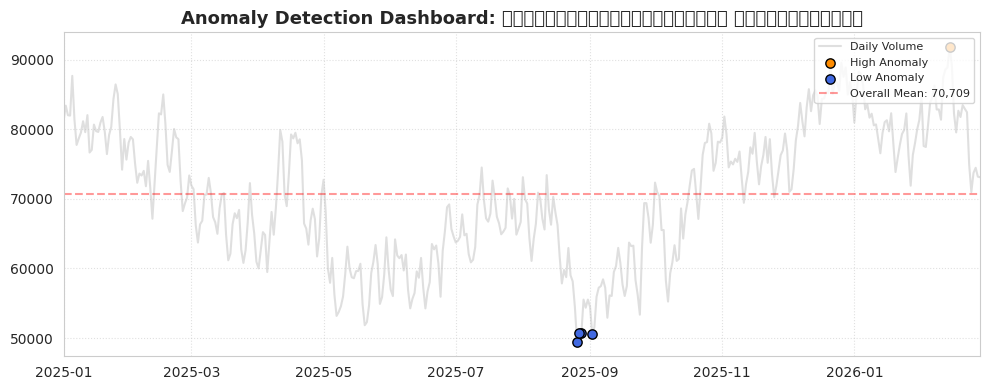


 📊 ANALYSIS REPORT: BTS SkyTrain 
Average Volume: 723,332 | SD: 146,827

[ 📉 SLUMP CHECK: ปริมาณต่ำกว่าปกติ (Z < -2) ]
Date         | Day        | Passengers   | Holiday Event
2025-03-28   | Friday     | 334,446      | -
2025-05-12   | Monday     | 386,193      | -
2025-06-03   | Tuesday    | 420,055      | -
2025-07-28   | Monday     | 424,014      | -

[ 📈 PEAK CHECK: ปริมาณสูงกว่าปกติ (Z > 2) ]
Date         | Day        | Passengers   | Holiday Event
2025-01-31   | Friday     | 1,206,443    | -
2025-01-30   | Thursday   | 1,178,856    | -
2025-01-29   | Wednesday  | 1,169,364    | วันตรุษจีน
2025-01-28   | Tuesday    | 1,108,058    | -
2025-01-27   | Monday     | 1,075,680    | -


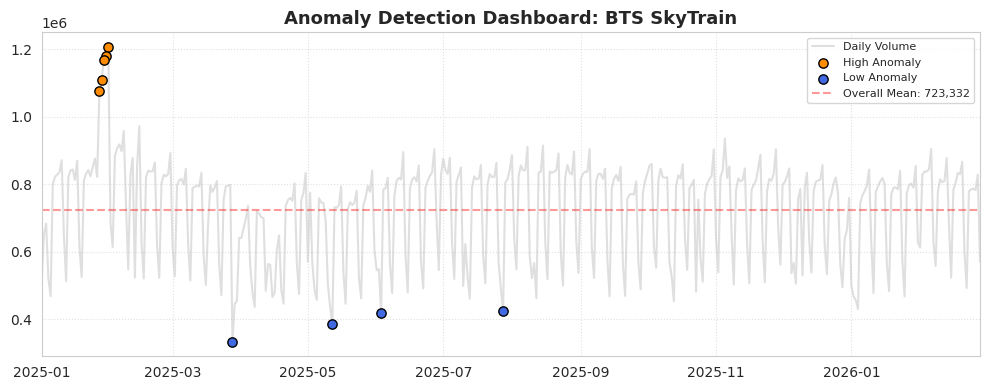


 📊 ANALYSIS REPORT: MRT Blue Line 
Average Volume: 428,587 | SD: 100,616

[ 📉 SLUMP CHECK: ปริมาณต่ำกว่าปกติ (Z < -2) ]
Date         | Day        | Passengers   | Holiday Event
2025-05-12   | Monday     | 198,521      | -
2025-03-28   | Friday     | 216,371      | -
2025-07-28   | Monday     | 220,947      | -
2025-06-03   | Tuesday    | 223,014      | -

[ 📈 PEAK CHECK: ปริมาณสูงกว่าปกติ (Z > 2) ]
Date         | Day        | Passengers   | Holiday Event
2025-01-31   | Friday     | 712,781      | -
2025-01-30   | Thursday   | 699,053      | -
2025-01-29   | Wednesday  | 696,352      | วันตรุษจีน


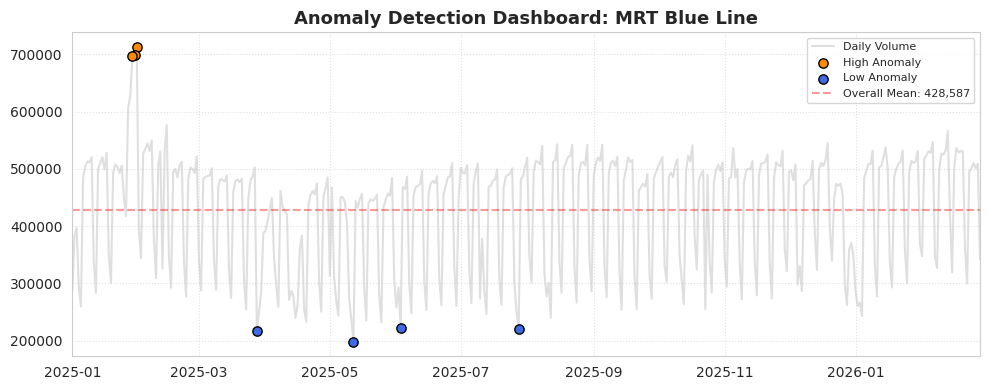


 📊 ANALYSIS REPORT: MRT Purple Line 
Average Volume: 67,672 | SD: 19,456

[ 📉 SLUMP CHECK: ปริมาณต่ำกว่าปกติ (Z < -2) ]
✅ Clean: ข้อมูลสม่ำเสมอ ไม่มีช่วงดิ่งลงผิดปกติ

[ 📈 PEAK CHECK: ปริมาณสูงกว่าปกติ (Z > 2) ]
Date         | Day        | Passengers   | Holiday Event
2025-01-31   | Friday     | 110,632      | -


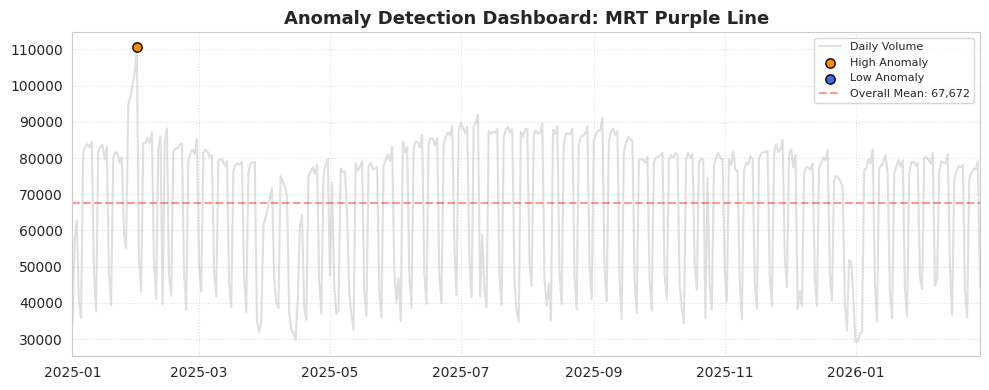


 📊 ANALYSIS REPORT: MRT Yellow Line 
Average Volume: 45,690 | SD: 9,663

[ 📉 SLUMP CHECK: ปริมาณต่ำกว่าปกติ (Z < -2) ]
Date         | Day        | Passengers   | Holiday Event
2025-03-28   | Friday     | 18,363       | -
2025-03-30   | Sunday     | 19,980       | -
2025-07-28   | Monday     | 25,358       | -
2025-05-12   | Monday     | 25,795       | -

[ 📈 PEAK CHECK: ปริมาณสูงกว่าปกติ (Z > 2) ]
Date         | Day        | Passengers   | Holiday Event
2025-01-31   | Friday     | 96,432       | -
2025-01-30   | Thursday   | 87,045       | -
2025-01-29   | Wednesday  | 85,525       | วันตรุษจีน
2025-01-28   | Tuesday    | 80,914       | -
2025-01-27   | Monday     | 78,010       | -


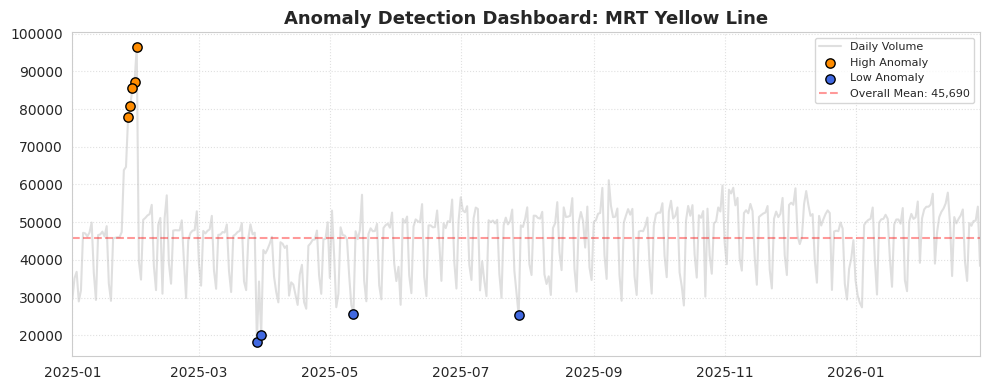


 📊 ANALYSIS REPORT: MRT Pink Line 
Average Volume: 62,084 | SD: 15,976

[ 📉 SLUMP CHECK: ปริมาณต่ำกว่าปกติ (Z < -2) ]
Date         | Day        | Passengers   | Holiday Event
2025-12-20   | Saturday   | 7,663        | -
2025-03-28   | Friday     | 28,298       | -
2026-01-02   | Friday     | 29,075       | -

[ 📈 PEAK CHECK: ปริมาณสูงกว่าปกติ (Z > 2) ]
Date         | Day        | Passengers   | Holiday Event
2025-01-31   | Friday     | 131,854      | -
2025-01-30   | Thursday   | 116,341      | -
2025-01-29   | Wednesday  | 114,987      | วันตรุษจีน
2025-01-28   | Tuesday    | 110,272      | -
2025-01-27   | Monday     | 107,080      | -


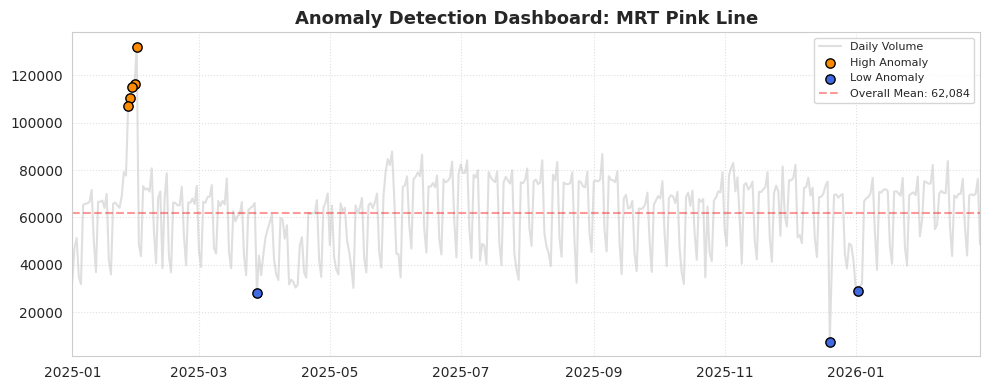


 📊 ANALYSIS REPORT: Airport Rail Link (ARL) 
Average Volume: 66,565 | SD: 11,719

[ 📉 SLUMP CHECK: ปริมาณต่ำกว่าปกติ (Z < -2) ]
Date         | Day        | Passengers   | Holiday Event
2025-03-28   | Friday     | 32,346       | -
2025-05-11   | Sunday     | 42,340       | -

[ 📈 PEAK CHECK: ปริมาณสูงกว่าปกติ (Z > 2) ]
Date         | Day        | Passengers   | Holiday Event
2025-01-31   | Friday     | 101,641      | -
2025-01-30   | Thursday   | 97,204       | -
2025-01-29   | Wednesday  | 93,669       | วันตรุษจีน
2025-01-28   | Tuesday    | 91,563       | -
2025-01-27   | Monday     | 90,310       | -


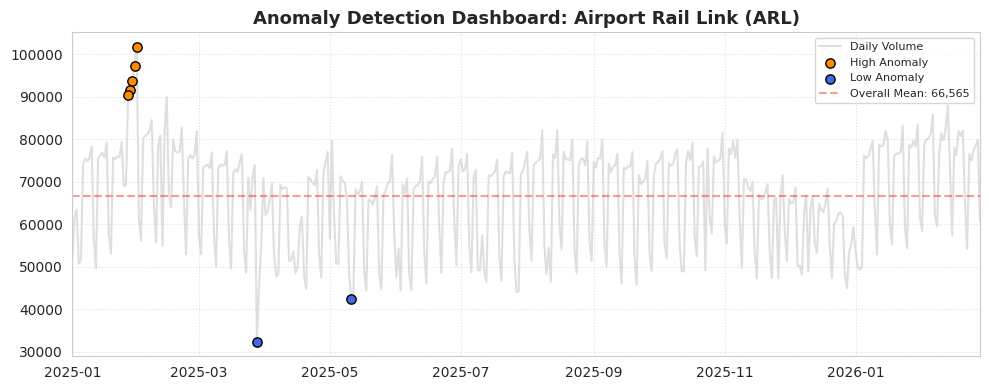


 📊 ANALYSIS REPORT: SRT Red Line 
Average Volume: 36,494 | SD: 7,452

[ 📉 SLUMP CHECK: ปริมาณต่ำกว่าปกติ (Z < -2) ]
Date         | Day        | Passengers   | Holiday Event
2025-03-28   | Friday     | 19,682       | -
2026-01-02   | Friday     | 20,865       | -
2025-03-29   | Saturday   | 21,548       | -
2025-12-28   | Sunday     | 21,552       | -

[ 📈 PEAK CHECK: ปริมาณสูงกว่าปกติ (Z > 2) ]
Date         | Day        | Passengers   | Holiday Event
2025-01-31   | Friday     | 61,216       | -
2026-02-06   | Friday     | 53,271       | -
2025-02-07   | Friday     | 52,003       | -


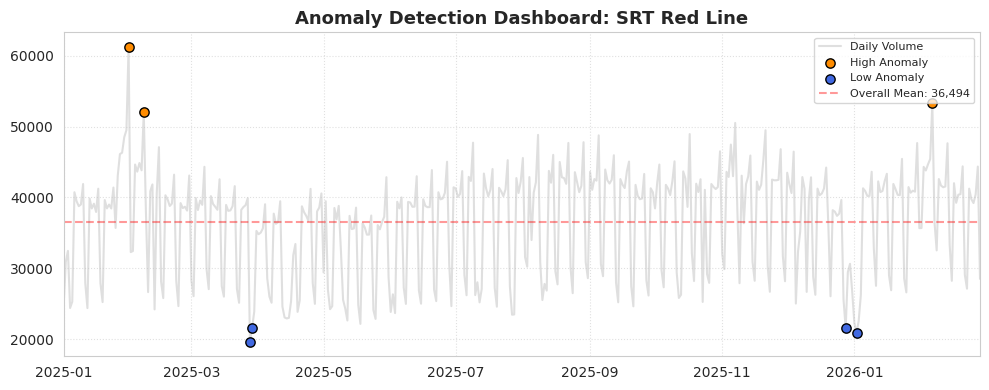

In [ ]:
# ============================================================
# 🔎 BATCH ANOMALY AUDIT: การตรวจสอบความผิดปกติรายโครงข่ายแบบเป็นระบบ
# ============================================================
# วัตถุประสงค์:
# 1. เพื่อตรวจหา "จุดรั่วไหลของข้อมูล" (Data Leaks) หรือ "วันที่ข้อมูลหายไป" ในทุกสายทาง
# 2. เพื่อเปรียบเทียบผลกระทบของวันหยุด (Holidays) ต่อการเดินทางแต่ละประเภท
#    (เช่น ท่าอากาศยานอาจจะมี Peak ในขณะที่รถไฟฟ้าในเมืองมี Slump ในวันเดียวกัน)

# --- 🛫 1. กลุ่มโครงข่ายการเดินทางระหว่างประเทศ ---
# ตรวจสอบสนามบินหลัก เพื่อดูช่วง Peak Season ของนักท่องเที่ยว (Arrivals)
check_anomalies('ท่าอากาศยานสุวรรณภูมิ ขาเข้าประเทศ')

# --- 🚇 2. กลุ่มโครงข่ายรถไฟฟ้าสายหลัก (Mainlines) ---
# เน้นตรวจสอบสายที่มีปริมาณผู้โดยสารสูง เพื่อดูความเสถียรของ Workforce
check_anomalies('รถไฟฟ้า BTS')
check_anomalies('รถไฟฟ้าสายสีน้ำเงิน')

# --- 🚊 3. กลุ่มรถไฟฟ้าสายรองและส่วนต่อขยาย (Feeder & Suburban Lines) ---
# ตรวจสอบสายใหม่ (ชมพู/เหลือง) เพื่อดูการเติบโตและจุดที่ผู้โดยสารแกว่งตัว
check_anomalies('รถไฟฟ้าสายสีม่วง')
check_anomalies('รถไฟฟ้าสายสีเหลือง')
check_anomalies('รถไฟฟ้าสายสีชมพู')

# --- 🚆 4. กลุ่มเชื่อมต่อพิเศษ (Specialized Connectors) ---
# ตรวจสอบสายเชื่อมสนามบินและรถไฟชานเมือง
check_anomalies('รถไฟฟ้า ARL')
check_anomalies('รถไฟฟ้าสายสีแดง')

# ============================================================
# 💡 คำแนะนำ: หลังรันคำสั่งนี้ ให้สังเกตค่า Z-Score
# หากพบวันที่ไม่มีชื่อวันหยุดกำกับ แต่มีค่า Z > 2 หรือ Z < -2
# วันนั้นอาจจะเป็น "Special Event" เช่น มีคอนเสิร์ตใหญ่หรือน้ำท่วมครับ